# ARIMA - SARIMA

## 1. Cài đặt và import thư viện

Cài đặt `pmdarima` nếu môi trường hiện tại chưa có thư viện này.

In [52]:
pip install -q pmdarima

Note: you may need to restart the kernel to use updated packages.


In [53]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")


In [54]:
# Config cho việc visualization

GREEN      = "#344f1e"
BLUE       = "#2f6f9f"
RED        = "#b5432f"
GRAY       = "#5f6b5d"
LIGHT_GREEN = "#eef4e8"
DARK = "#111827"
ORANGE = "#F59E0B"


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

## 2. Chuẩn bị và chia dữ liệu

Ta nạp dữ liệu PM2.5 theo giờ (1H), chia train/test theo mốc thời gian đã định.

In [55]:
train = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-hour-new/PM25_2026_Q1_train.csv")
test = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-hour-new/PM25_2026_Q1_test_1week.csv")

train['Local Time'] = pd.to_datetime(train['Local Time'])
test['Local Time'] = pd.to_datetime(test['Local Time'])

# Chuyển DL về dạng series
train = pd.Series(
    train["PM25"].values,
    index=train["Local Time"],
    name="PM25" 
)

test = pd.Series(
    test["PM25"].values,
    index=test["Local Time"],
    name="PM25" 
)

train = train.asfreq('H')
test = test.asfreq('H')

print(train.head().to_string())
print(f"Train: {train.index[0]} đến {train.index[-1]} ({len(train)} quan sát)")
print(f"Test:  {test.index[0]} đến {test.index[-1]} ({len(test)} quan sát)")

Local Time
2026-01-01 00:00:00    38.4
2026-01-01 01:00:00    39.3
2026-01-01 02:00:00    38.4
2026-01-01 03:00:00    36.8
2026-01-01 04:00:00    35.5
Freq: h
Train: 2026-01-01 00:00:00 đến 2026-03-24 23:00:00 (1992 quan sát)
Test:  2026-03-25 00:00:00 đến 2026-03-31 23:00:00 (168 quan sát)


## 3. Trực quan hóa tập huấn luyện

Trước khi mô hình hóa, ta quan sát chuỗi trên tập huấn luyện để nhận diện sơ bộ chu kỳ, biên độ dao động và các giai đoạn biến động mạnh.

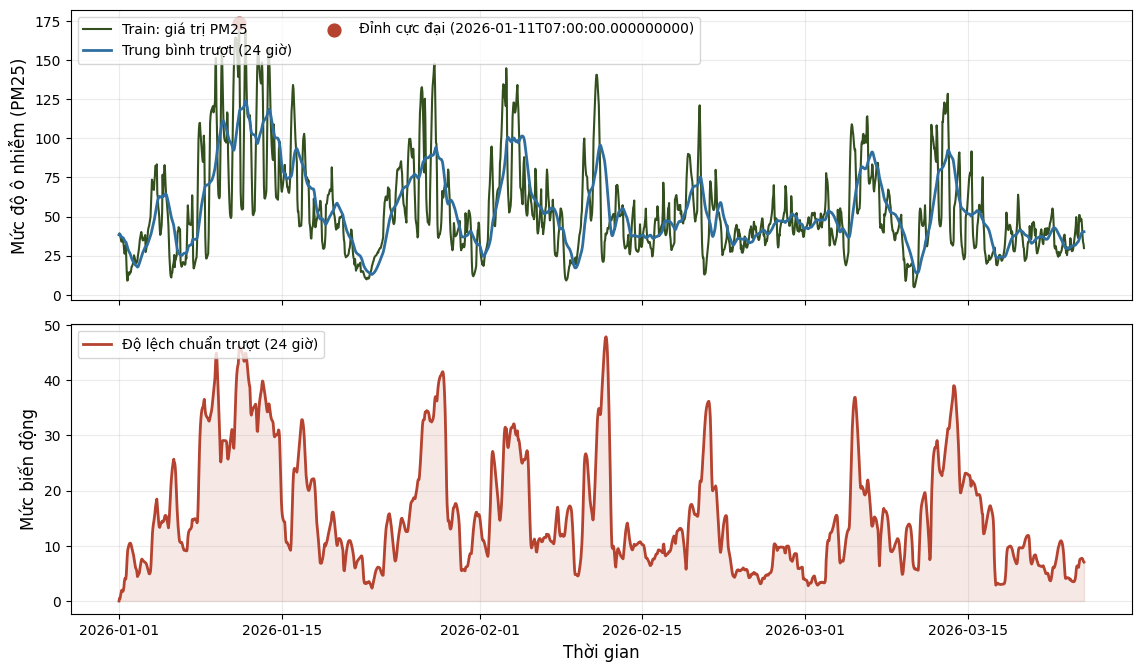

In [56]:
t = train.index.to_numpy()
y = train.to_numpy()

window = 24 

rolling_mean = np.array([np.mean(y[max(0, i - window + 1): i + 1]) for i in range(len(y))])
rolling_std  = np.array([np.std( y[max(0, i - window + 1): i + 1]) for i in range(len(y))])
peak_idx = np.argmax(y)

fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.8), sharex=True)

ax = axes[0]
ax.plot(t, y, color=GREEN, linewidth=1.5, label="Train: giá trị PM25")
ax.plot(t, rolling_mean, color=BLUE, linewidth=2.0, label="Trung bình trượt (24 giờ)")
ax.scatter([t[peak_idx]], [y[peak_idx]], s=85, color=RED, zorder=5,
           label=f"Đỉnh cực đại ({t[peak_idx]})")
ax.set_ylabel("Mức độ ô nhiễm (PM25)")
ax.legend(loc="upper left", ncol=2, frameon=True)
ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(t, rolling_std, color=RED, linewidth=2.0, label="Độ lệch chuẩn trượt (24 giờ)")
ax.fill_between(t, 0, rolling_std, color=RED, alpha=0.12)
ax.set_xlabel("Thời gian")
ax.set_ylabel("Mức biến động")
ax.legend(loc="upper left", frameon=True)
ax.grid(alpha=0.25)

fig.tight_layout(pad=1.0)
plt.show()

## 4. Kiểm tra tính dừng và chọn \(d\)

Ta dùng kiểm định Augmented Dickey–Fuller (ADF) cho chuỗi gốc và chuỗi sau sai phân bậc một.

In [57]:
raw_adf_stat, raw_p_value, *_ = adfuller(train)

diff_train = train.diff().dropna()
diff_adf_stat, diff_p_value, *_ = adfuller(diff_train)

log_train = np.log(train.replace(0, np.nan)).dropna()
log_adf_stat, log_p_value, *_ = adfuller(log_train)

diff_log_train = log_train.diff().dropna()
diff_log_adf_stat, diff_log_p_value, *_ = adfuller(diff_log_train)

print(f"ADF statistic train series: {raw_adf_stat:.4f}")
print(f"ADF p-value train series: {raw_p_value:.4f}")
print(f"ADF statistic first difference: {diff_adf_stat:.4f}")
print(f"ADF p-value first difference: {diff_p_value:.4e}")
print(f"ADF statistic log-transformed: {log_adf_stat:.4f}")
print(f"ADF p-value log-transformed: {log_p_value:.4e}")
print(f"ADF statistic log-differenced: {diff_log_adf_stat:.4f}")
print(f"ADF p-value log-differenced: {diff_log_p_value:.4e}")

ADF statistic train series: -4.2358
ADF p-value train series: 0.0006
ADF statistic first difference: -10.1295
ADF p-value first difference: 8.9959e-18
ADF statistic log-transformed: -5.7125
ADF p-value log-transformed: 7.2456e-07
ADF statistic log-differenced: -9.1544
ADF p-value log-differenced: 2.6338e-15


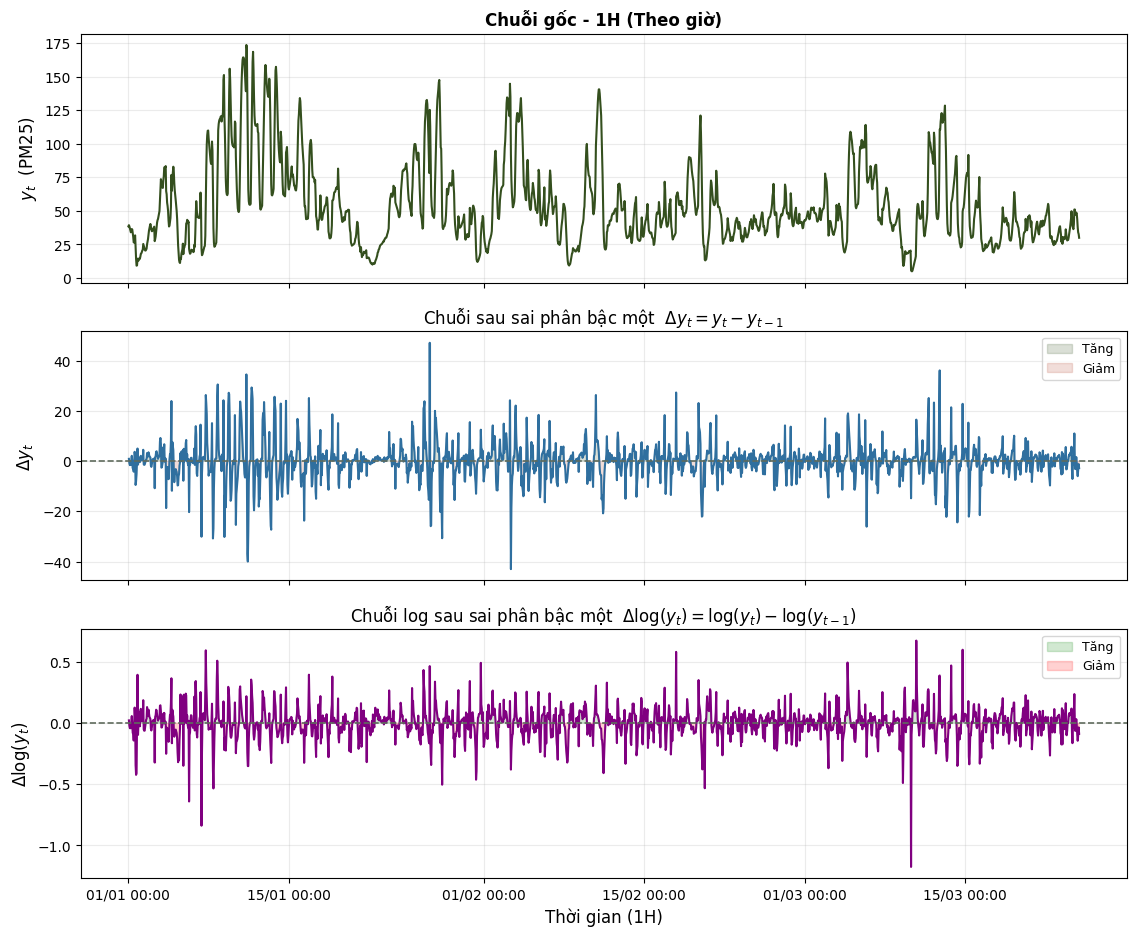

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Trích xuất dữ liệu
t = train.index.to_numpy()
y = train.to_numpy()

# Tính sai phân
dy = np.diff(y)

# Tính log và sai phân của log (dùng log1p để an toàn nếu có giá trị 0)
y_log = np.log1p(np.asarray(y, dtype=float)) 
dy_log = np.diff(y_log)

t_diff = t[1:]

fig, axes = plt.subplots(3, 1, figsize=(11.5, 9.5), sharex=True)

# Đồng bộ kích thước mảng
t_np = t
y_np = np.asarray(y, dtype=float)
td_np = t_diff
dy_np = np.asarray(dy, dtype=float)
dy_log_np = np.asarray(dy_log, dtype=float)

n = min(len(td_np), len(dy_np), len(dy_log_np))
td_np = td_np[:n]
dy_np = dy_np[:n]
dy_log_np = dy_log_np[:n]

# Điều kiện hợp lệ (Chỉ kiểm tra trên mảng số, KHÔNG check trên mảng thời gian datetime)
valid = np.isfinite(dy_np)
valid_log = np.isfinite(dy_log_np)

# --- Subplot 1: Chuỗi gốc ---
a0 = axes[0]
a0.plot(t_np, y_np, color=GREEN, linewidth=1.5)
a0.set_title("Chuỗi gốc - 1H (Theo giờ)", fontsize=12, fontweight='bold')
a0.set_ylabel(r"$y_t$  (PM25)")
a0.grid(alpha=0.25)

# --- Subplot 2: Sai phân bậc 1 ---
a1 = axes[1]
a1.plot(td_np[valid], dy_np[valid], color=BLUE, linewidth=1.5)
a1.axhline(0, color=GRAY, linewidth=1.2, linestyle="--")
a1.fill_between(td_np[valid], 0, dy_np[valid], where=(dy_np[valid] >= 0), color=GREEN, alpha=0.18, label="Tăng")
a1.fill_between(td_np[valid], 0, dy_np[valid], where=(dy_np[valid] <  0), color=RED,   alpha=0.18, label="Giảm")
a1.set_title(r"Chuỗi sau sai phân bậc một  $\Delta y_t = y_t - y_{t-1}$", fontsize=12)
a1.set_ylabel(r"$\Delta y_t$")
a1.legend(loc="upper right", frameon=True, fontsize=9)
a1.grid(alpha=0.25)

# --- Subplot 3: Log và Sai phân bậc 1 ---
a2 = axes[2] 
a2.plot(td_np[valid_log], dy_log_np[valid_log], color='purple', linewidth=1.5) 
a2.axhline(0, color=GRAY, linewidth=1.2, linestyle="--")
a2.fill_between(td_np[valid_log], 0, dy_log_np[valid_log], where=(dy_log_np[valid_log] >= 0), color='green', alpha=0.18, label="Tăng")
a2.fill_between(td_np[valid_log], 0, dy_log_np[valid_log], where=(dy_log_np[valid_log] <  0), color='red',   alpha=0.18, label="Giảm")
a2.set_title(r"Chuỗi log sau sai phân bậc một  $\Delta \log(y_t) = \log(y_t) - \log(y_{t-1})$", fontsize=12)
a2.set_ylabel(r"$\Delta \log(y_t)$")
a2.set_xlabel("Thời gian (1H)")
a2.legend(loc="upper right", frameon=True, fontsize=9)
a2.grid(alpha=0.25)

# Format hiển thị ngày giờ trên trục X cho cả 3 đồ thị
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:00'))

fig.tight_layout(pad=1.2)
plt.show()

## 5. Nhận diện \(p,q\) bằng ACF/PACF

Ta quan sát ACF và PACF của chuỗi sai phân để xác định miền tìm kiếm ban đầu cho \(p\) và \(q\).

## 6. Lựa chọn mô hình bằng AIC

Với dữ liệu 1H, sau khi thử nghiệm auto_arima cho thấy các mô hình tốt nhất là:
- ARIMA(13, 1, 14)
- SARIMA(1, 1, 0)(1, 1, 0)[24]

Hai mô hình này được huấn luyện và đánh giá trực tiếp ở bước 7 trở đi.

## 7. Huấn luyện mô hình SARIMA được chọn

Sau khi chọn được cấu hình tốt nhất theo AIC, ta ước lượng mô hình cuối cùng trên toàn bộ tập huấn luyện bằng `statsmodels`.

In [65]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

## 8. Chẩn đoán phần dư

Ta kiểm tra phần dư bằng chuỗi phần dư theo thời gian, ACF phần dư và kiểm định Ljung–Box.

## 9. Dự báo trên tập kiểm tra

Sau khi mô hình đạt yêu cầu ở bước chẩn đoán phần dư, ta dự báo trên tập kiểm tra và đánh giá sai số.

Đang huấn luyện ARIMA(13,1,14) trên dữ liệu 1H...
Mô hình được chọn: ARIMA(13,1,14)
                               SARIMAX Results                                
Dep. Variable:                   PM25   No. Observations:                 1992
Model:               ARIMA(13, 1, 14)   Log Likelihood               -6071.122
Date:                Mon, 04 May 2026   AIC                          12198.245
Time:                        17:08:30   BIC                          12354.732
Sample:                    01-01-2026   HQIC                         12255.739
                         - 03-24-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2037      0.793      1.519      0.129      -0.350       2.757
ar.L2         -0.6575      1.658     -0.397    

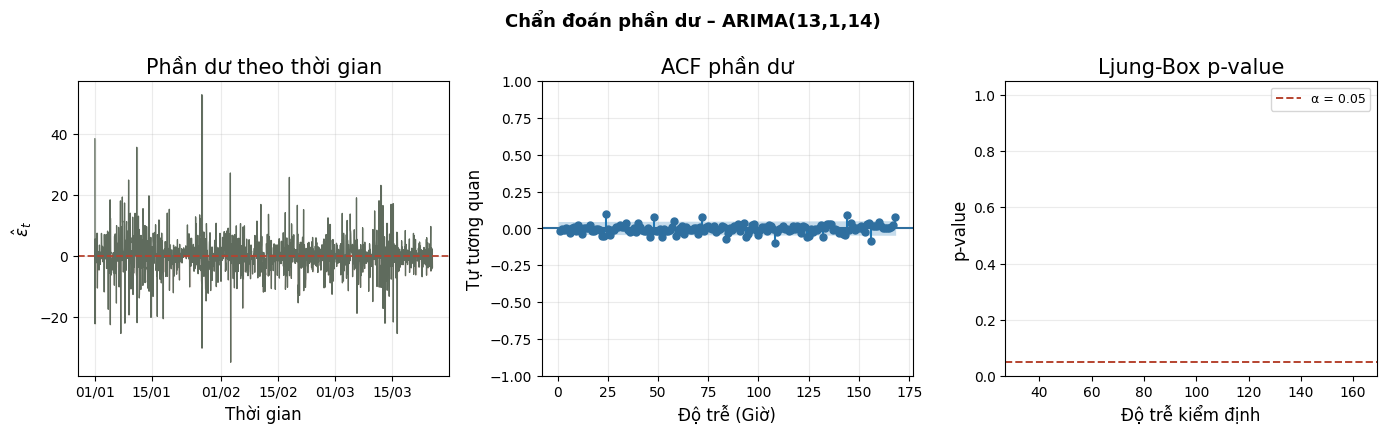


Metric        Giá trị
----------------------
MAE           14.8329
RMSE          19.1360
MAPE           25.20%
WAPE           28.97%
R²            -0.5360


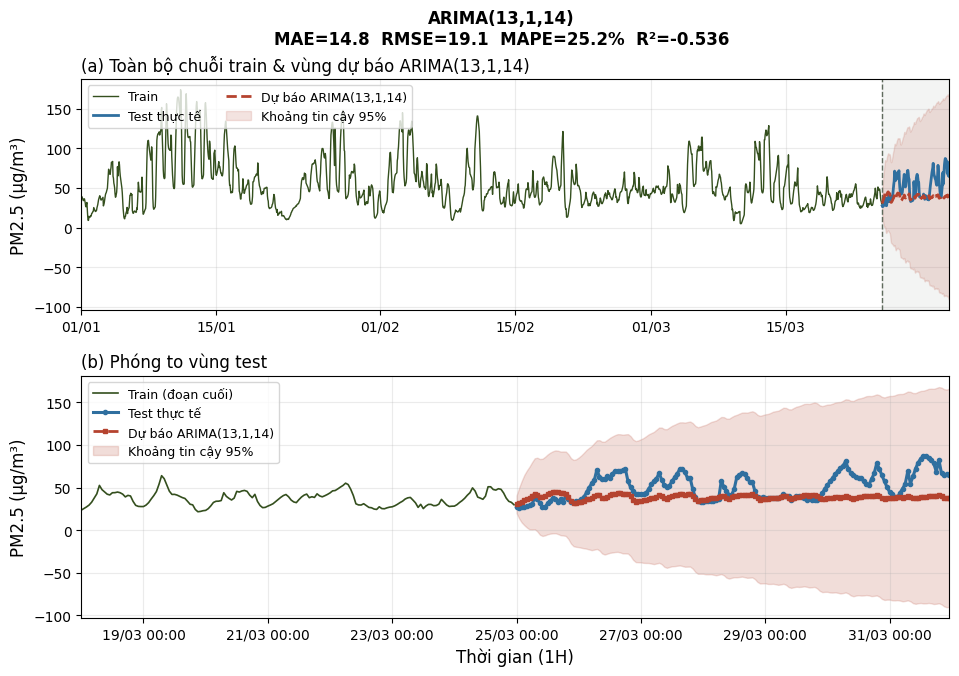

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cấu hình màu sắc
GREEN, BLUE, RED, GRAY = "#344f1e", "#2f6f9f", "#b5432f", "#5f6b5d"

# ==============================================================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH ARIMA(13, 1, 14)
# ==============================================================================
# ---> ĐIỂM SỬA 1: Cập nhật tham số mô hình
selected_order = (13, 1, 14)
p, d, q = selected_order
model_label = f"ARIMA({p},{d},{q})"

print(f"Đang huấn luyện {model_label} trên dữ liệu 1H...")

# Lấy dữ liệu train an toàn
y_train_safe = train['PM25'] if isinstance(train, pd.DataFrame) else train

final_model = ARIMA(
    y_train_safe,
    order=selected_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_result = final_model.fit()

print(f"Mô hình được chọn: {model_label}")
print(final_result.summary())

# ==============================================================================
# 2. CHẨN ĐOÁN PHẦN DƯ (DIAGNOSTICS)
# ==============================================================================
residuals = final_result.resid.dropna()

model_df = p + q 
# ---> ĐIỂM SỬA 2: Mở rộng khung nhìn đánh giá phần dư lên 1 tuần (168 giờ)
max_lag  = 168  

lb_lags = list(range(model_df + 1, max_lag + 1))
if not lb_lags:
    raise ValueError(f"model_df={model_df} >= max_lag={max_lag}, không còn lag hợp lệ.")

ljung_box_result = acorr_ljungbox(
    residuals, lags=lb_lags, model_df=model_df, return_df=True
)

print(f"\nMô hình: {model_label}")
print(f"model_df = p + q = {model_df}")
print(ljung_box_result.tail(10))

resid_values = residuals.to_numpy(dtype=float)
resid_time   = residuals.index
lags_full    = ljung_box_result.index.to_numpy()
pvals_full   = ljung_box_result["lb_pvalue"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))

# ── Chuỗi phần dư ────────────────────────────────────────────────────────
axes[0].plot(resid_time, resid_values, color=GRAY, linewidth=0.9)
axes[0].axhline(0, color=RED, linestyle="--", linewidth=1.3)
axes[0].fill_between(resid_time, 0, resid_values, where=(resid_values >= 0), color=GREEN, alpha=0.18)
axes[0].fill_between(resid_time, 0, resid_values, where=(resid_values <  0), color=RED,   alpha=0.18)
axes[0].set_title("Phần dư theo thời gian")
axes[0].set_xlabel("Thời gian")
axes[0].set_ylabel(r"$\hat{\varepsilon}_t$")
axes[0].grid(alpha=0.25)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# ── ACF phần dư ──────────────────────────────────────────────────────────
sm_plot_acf(residuals, ax=axes[1], lags=max_lag, zero=False, color=BLUE, alpha=0.05)
axes[1].set_title("ACF phần dư")
axes[1].set_xlabel("Độ trễ (Giờ)")
axes[1].set_ylabel("Tự tương quan")
axes[1].grid(alpha=0.25)

# ── Ljung-Box p-values ────────────────────────────────────────────────────
axes[2].bar(lags_full, pvals_full, color=[GREEN if p > 0.05 else RED for p in pvals_full], alpha=0.82, width=0.7)
axes[2].axhline(0.05, color=RED, linestyle="--", linewidth=1.4, label="α = 0.05")
axes[2].set_title("Ljung-Box p-value")
axes[2].set_xlabel("Độ trễ kiểm định")
axes[2].set_ylabel("p-value")
axes[2].set_xlim(model_df, max_lag + 1)
axes[2].set_ylim(0, 1.05)
axes[2].legend(frameon=True, fontsize=9)
axes[2].grid(axis="y", alpha=0.25)

fig.suptitle(f"Chẩn đoán phần dư – {model_label}", fontsize=13, fontweight="bold")
fig.tight_layout(pad=1.2)
plt.show()

# ==============================================================================
# 3. DỰ BÁO VÀ ĐÁNH GIÁ (METRICS)
# ==============================================================================
n_steps         = len(test)
forecast_result = final_result.get_forecast(steps=n_steps)
arima_forecast  = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int()

y_test_safe = np.asarray(test['PM25'] if isinstance(test, pd.DataFrame) else test, dtype=float).flatten()

mae  = mean_absolute_error(y_test_safe, arima_forecast)
rmse = np.sqrt(mean_squared_error(y_test_safe, arima_forecast))
r2   = 1 - np.sum((y_test_safe - arima_forecast)**2) / np.sum((y_test_safe - y_test_safe.mean())**2)
wape = np.sum(np.abs(y_test_safe - arima_forecast)) / np.sum(np.abs(y_test_safe)) * 100

nonzero_mask = y_test_safe != 0
mape = np.mean(np.abs(
    (y_test_safe[nonzero_mask] - arima_forecast.values[nonzero_mask]) / y_test_safe[nonzero_mask]
)) * 100

print(f"\n{'Metric':<8} {'Giá trị':>12}")
print("-" * 22)
print(f"{'MAE':<8} {mae:>12.4f}")
print(f"{'RMSE':<8} {rmse:>12.4f}")
print(f"{'MAPE':<8} {mape:>11.2f}%")
print(f"{'WAPE':<8} {wape:>11.2f}%")
print(f"{'R²':<8} {r2:>12.4f}")

# ==============================================================================
# 4. TRỰC QUAN HÓA KẾT QUẢ DỰ BÁO
# ==============================================================================
train_time = (pd.to_datetime(train['Local Time']) if isinstance(train, pd.DataFrame) and 'Local Time' in train.columns else train.index).to_numpy()
test_time  = (pd.to_datetime(test['Local Time']) if isinstance(test, pd.DataFrame) and 'Local Time' in test.columns else test.index).to_numpy()

# Lấy lại biến mảng đã chuyển thành số thực
y_train_safe = np.asarray(y_train_safe, dtype=float).flatten()
fc_arr       = np.asarray(arima_forecast, dtype=float).ravel()
lower        = conf_int.iloc[:, 0].to_numpy()
upper        = conf_int.iloc[:, 1].to_numpy()

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(11.2, 7.0), sharey=False,
    gridspec_kw={"height_ratios": [1.0, 1.05], "hspace": 0.28}
)

ax0.plot(train_time, y_train_safe, color=GREEN, linewidth=1.0, label="Train")
ax0.plot(test_time,  y_test_safe,  color=BLUE,  linewidth=2.0, label="Test thực tế", zorder=4)
ax0.plot(test_time,  fc_arr,       color=RED,   linewidth=2.0, linestyle="--", label=f"Dự báo {model_label}", zorder=5)
ax0.fill_between(test_time, lower, upper, color=RED, alpha=0.15, label="Khoảng tin cậy 95%", zorder=2)
ax0.axvspan(test_time[0], test_time[-1], color=GRAY, alpha=0.07)
ax0.axvline(test_time[0], color=GRAY, linestyle="--", linewidth=1.0)
ax0.set_ylabel("PM2.5 (µg/m³)")
ax0.set_title(f"(a) Toàn bộ chuỗi train & vùng dự báo {model_label}", loc="left", fontsize=12)
ax0.legend(loc="upper left", frameon=True, fontsize=9, ncol=2)
ax0.grid(alpha=0.25)
ax0.set_xlim(train_time[0], test_time[-1])
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# ---> ĐIỂM SỬA 3: Phóng to 168 bước (1 tuần dữ liệu 1H)
z_lo = train_time[-168] if len(train_time) >= 168 else train_time[0]
mask = train_time >= z_lo
ax1.plot(train_time[mask], y_train_safe[mask], color=GREEN, linewidth=1.2, label="Train (đoạn cuối)")
ax1.plot(test_time, y_test_safe, color=BLUE,  linewidth=2.2, marker="o", markersize=3, label="Test thực tế")
ax1.plot(test_time, fc_arr,      color=RED,   linewidth=2.0, linestyle="--", marker="s", markersize=3, label=f"Dự báo {model_label}")
ax1.fill_between(test_time, lower, upper, color=RED, alpha=0.18, label="Khoảng tin cậy 95%")
ax1.set_xlabel("Thời gian (1H)")
ax1.set_ylabel("PM2.5 (µg/m³)")
ax1.set_title("(b) Phóng to vùng test", loc="left", fontsize=12)
ax1.legend(loc="upper left", frameon=True, fontsize=9)
ax1.grid(alpha=0.25)
ax1.set_xlim(z_lo, test_time[-1])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:00'))

metrics_str = f"MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  R²={r2:.3f}"
fig.suptitle(f"{model_label}\n{metrics_str}", fontsize=12, fontweight="bold")
fig.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.93])
plt.show()

Đang huấn luyện SARIMA(1,1,0)(1,1,0)[24] trên dữ liệu 1H (Có thể mất một chút thời gian)...
Mô hình được chọn: SARIMA(1,1,0)(1,1,0)[24]
                                    SARIMAX Results                                     
Dep. Variable:                             PM25   No. Observations:                 1992
Model:             ARIMA(1, 1, 0)x(1, 1, 0, 24)   Log Likelihood               -6227.559
Date:                          Mon, 04 May 2026   AIC                          12461.117
Time:                                  17:08:32   BIC                          12477.831
Sample:                              01-01-2026   HQIC                         12467.263
                                   - 03-24-2026                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

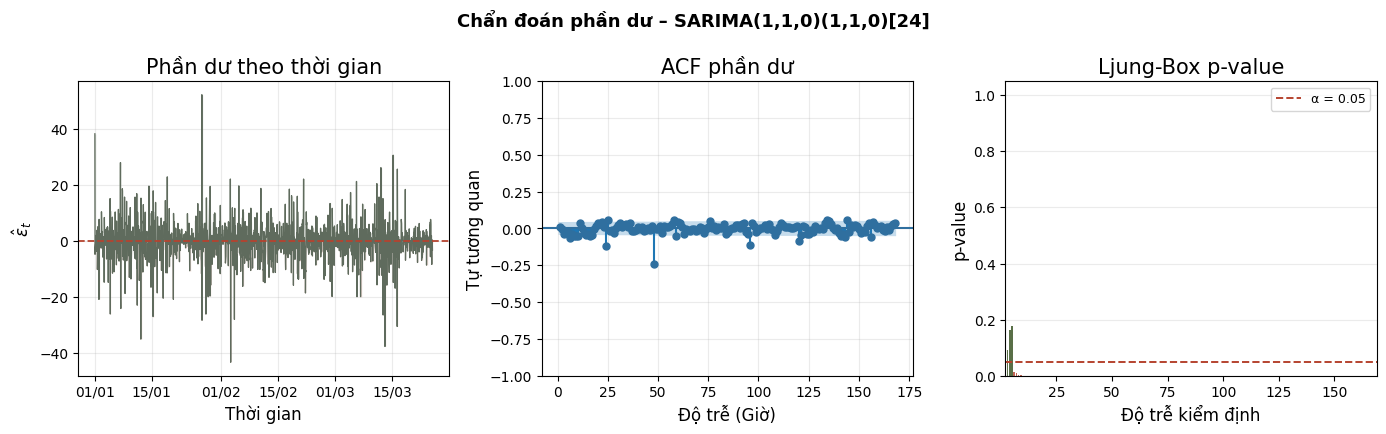


Metric        Giá trị
----------------------
MAE           16.4224
RMSE          20.3936
MAPE           28.39%
WAPE           32.07%
R²            -0.7445


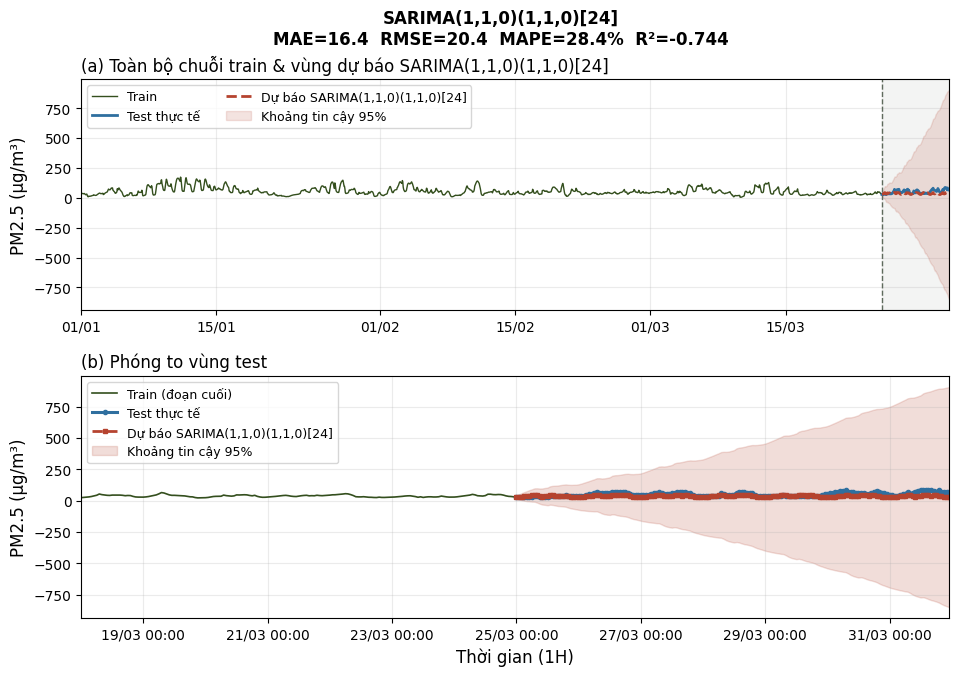

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cấu hình màu sắc
GREEN, BLUE, RED, GRAY = "#344f1e", "#2f6f9f", "#b5432f", "#5f6b5d"

# ==============================================================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH SARIMA(1, 1, 0)(1, 1, 0)[24]
# ==============================================================================
# ---> ĐIỂM SỬA 1: Khai báo tham số ARIMA và Mùa vụ (Seasonal)
selected_order = (1, 1, 0)
selected_seasonal = (1, 1, 0, 24)

p, d, q = selected_order
P, D, Q, m = selected_seasonal
model_label = f"SARIMA({p},{d},{q})({P},{D},{Q})[{m}]"

print(f"Đang huấn luyện {model_label} trên dữ liệu 1H (Có thể mất một chút thời gian)...")

# Lấy dữ liệu train an toàn
y_train_safe = train['PM25'] if isinstance(train, pd.DataFrame) else train

final_model = ARIMA(
    y_train_safe,
    order=selected_order,
    seasonal_order=selected_seasonal, # Bổ sung thành phần mùa vụ vào hàm
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_result = final_model.fit()

print(f"Mô hình được chọn: {model_label}")
print(final_result.summary())

# ==============================================================================
# 2. CHẨN ĐOÁN PHẦN DƯ (DIAGNOSTICS)
# ==============================================================================
residuals = final_result.resid.dropna()

# ---> ĐIỂM SỬA 2: Bậc tự do hiệu chỉnh cho SARIMA = p + q + P + Q
model_df = p + q + P + Q 
max_lag  = 168  # Kiểm tra độ tự tương quan của phần dư lên đến 1 tuần (168 giờ)

lb_lags = list(range(model_df + 1, max_lag + 1))
if not lb_lags:
    raise ValueError(f"model_df={model_df} >= max_lag={max_lag}, không còn lag hợp lệ.")

ljung_box_result = acorr_ljungbox(
    residuals, lags=lb_lags, model_df=model_df, return_df=True
)

print(f"\nMô hình: {model_label}")
print(f"model_df = p + q + P + Q = {model_df}")
print(ljung_box_result.tail(10))

resid_values = residuals.to_numpy(dtype=float)
resid_time   = residuals.index
lags_full    = ljung_box_result.index.to_numpy()
pvals_full   = ljung_box_result["lb_pvalue"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))

# ── Chuỗi phần dư ────────────────────────────────────────────────────────
axes[0].plot(resid_time, resid_values, color=GRAY, linewidth=0.9)
axes[0].axhline(0, color=RED, linestyle="--", linewidth=1.3)
axes[0].fill_between(resid_time, 0, resid_values, where=(resid_values >= 0), color=GREEN, alpha=0.18)
axes[0].fill_between(resid_time, 0, resid_values, where=(resid_values <  0), color=RED,   alpha=0.18)
axes[0].set_title("Phần dư theo thời gian")
axes[0].set_xlabel("Thời gian")
axes[0].set_ylabel(r"$\hat{\varepsilon}_t$")
axes[0].grid(alpha=0.25)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# ── ACF phần dư ──────────────────────────────────────────────────────────
sm_plot_acf(residuals, ax=axes[1], lags=max_lag, zero=False, color=BLUE, alpha=0.05)
axes[1].set_title("ACF phần dư")
axes[1].set_xlabel("Độ trễ (Giờ)")
axes[1].set_ylabel("Tự tương quan")
axes[1].grid(alpha=0.25)

# ── Ljung-Box p-values ────────────────────────────────────────────────────
axes[2].bar(lags_full, pvals_full, color=[GREEN if p > 0.05 else RED for p in pvals_full], alpha=0.82, width=0.7)
axes[2].axhline(0.05, color=RED, linestyle="--", linewidth=1.4, label="α = 0.05")
axes[2].set_title("Ljung-Box p-value")
axes[2].set_xlabel("Độ trễ kiểm định")
axes[2].set_ylabel("p-value")
axes[2].set_xlim(model_df, max_lag + 1)
axes[2].set_ylim(0, 1.05)
axes[2].legend(frameon=True, fontsize=9)
axes[2].grid(axis="y", alpha=0.25)

fig.suptitle(f"Chẩn đoán phần dư – {model_label}", fontsize=13, fontweight="bold")
fig.tight_layout(pad=1.2)
plt.show()

# ==============================================================================
# 3. DỰ BÁO VÀ ĐÁNH GIÁ (METRICS)
# ==============================================================================
n_steps         = len(test)
forecast_result = final_result.get_forecast(steps=n_steps)
sarima_forecast = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int()

y_test_safe = np.asarray(test['PM25'] if isinstance(test, pd.DataFrame) else test, dtype=float).flatten()

mae  = mean_absolute_error(y_test_safe, sarima_forecast)
rmse = np.sqrt(mean_squared_error(y_test_safe, sarima_forecast))
r2   = 1 - np.sum((y_test_safe - sarima_forecast)**2) / np.sum((y_test_safe - y_test_safe.mean())**2)
wape = np.sum(np.abs(y_test_safe - sarima_forecast)) / np.sum(np.abs(y_test_safe)) * 100

nonzero_mask = y_test_safe != 0
mape = np.mean(np.abs(
    (y_test_safe[nonzero_mask] - sarima_forecast.values[nonzero_mask]) / y_test_safe[nonzero_mask]
)) * 100

print(f"\n{'Metric':<8} {'Giá trị':>12}")
print("-" * 22)
print(f"{'MAE':<8} {mae:>12.4f}")
print(f"{'RMSE':<8} {rmse:>12.4f}")
print(f"{'MAPE':<8} {mape:>11.2f}%")
print(f"{'WAPE':<8} {wape:>11.2f}%")
print(f"{'R²':<8} {r2:>12.4f}")

# ==============================================================================
# 4. TRỰC QUAN HÓA KẾT QUẢ DỰ BÁO
# ==============================================================================
train_time = (pd.to_datetime(train['Local Time']) if isinstance(train, pd.DataFrame) and 'Local Time' in train.columns else train.index).to_numpy()
test_time  = (pd.to_datetime(test['Local Time']) if isinstance(test, pd.DataFrame) and 'Local Time' in test.columns else test.index).to_numpy()

y_train_safe = np.asarray(y_train_safe, dtype=float).flatten()
fc_arr       = np.asarray(sarima_forecast, dtype=float).ravel()
lower        = conf_int.iloc[:, 0].to_numpy()
upper        = conf_int.iloc[:, 1].to_numpy()

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(11.2, 7.0), sharey=False,
    gridspec_kw={"height_ratios": [1.0, 1.05], "hspace": 0.28}
)

ax0.plot(train_time, y_train_safe, color=GREEN, linewidth=1.0, label="Train")
ax0.plot(test_time,  y_test_safe,  color=BLUE,  linewidth=2.0, label="Test thực tế", zorder=4)
ax0.plot(test_time,  fc_arr,       color=RED,   linewidth=2.0, linestyle="--", label=f"Dự báo {model_label}", zorder=5)
ax0.fill_between(test_time, lower, upper, color=RED, alpha=0.15, label="Khoảng tin cậy 95%", zorder=2)
ax0.axvspan(test_time[0], test_time[-1], color=GRAY, alpha=0.07)
ax0.axvline(test_time[0], color=GRAY, linestyle="--", linewidth=1.0)
ax0.set_ylabel("PM2.5 (µg/m³)")
ax0.set_title(f"(a) Toàn bộ chuỗi train & vùng dự báo {model_label}", loc="left", fontsize=12)
ax0.legend(loc="upper left", frameon=True, fontsize=9, ncol=2)
ax0.grid(alpha=0.25)
ax0.set_xlim(train_time[0], test_time[-1])
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# Phóng to 168 bước (1 tuần dữ liệu 1H)
z_lo = train_time[-168] if len(train_time) >= 168 else train_time[0]
mask = train_time >= z_lo
ax1.plot(train_time[mask], y_train_safe[mask], color=GREEN, linewidth=1.2, label="Train (đoạn cuối)")
ax1.plot(test_time, y_test_safe, color=BLUE,  linewidth=2.2, marker="o", markersize=3, label="Test thực tế")
ax1.plot(test_time, fc_arr,      color=RED,   linewidth=2.0, linestyle="--", marker="s", markersize=3, label=f"Dự báo {model_label}")
ax1.fill_between(test_time, lower, upper, color=RED, alpha=0.18, label="Khoảng tin cậy 95%")
ax1.set_xlabel("Thời gian (1H)")
ax1.set_ylabel("PM2.5 (µg/m³)")
ax1.set_title("(b) Phóng to vùng test", loc="left", fontsize=12)
ax1.legend(loc="upper left", frameon=True, fontsize=9)
ax1.grid(alpha=0.25)
ax1.set_xlim(z_lo, test_time[-1])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:00'))

metrics_str = f"MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  R²={r2:.3f}"
fig.suptitle(f"{model_label}\n{metrics_str}", fontsize=12, fontweight="bold")
fig.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.93])
plt.show()

## ARIMAX - 8 biến ngoại sinh

Đang huấn luyện ARIMAX(3, 0, 1) với 8 biến ngoại sinh trên dữ liệu 1H...
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Temperature           0.0238      0.004      6.771      0.000       0.017       0.031
Clouds            -2.483e-05   8.13e-05     -0.305      0.760      -0.000       0.000
Wind Speed           -0.0027      0.001     -2.610      0.009      -0.005      -0.001
Precipitation        -0.0159      0.002     -9.647      0.000      -0.019      -0.013
Pressure              0.0023      0.000     22.004      0.000       0.002       0.002
Relative Humidity     0.0052      0.001      9.153      0.000       0.004       0.006
SO2                   0.0043      0.001      5.284      0.000       0.003       0.006
NO2                   0.0140      0.001     23.520      0.000       0.013       0.015
ar.L1                 0.7744      1.737      0.446      0.656      

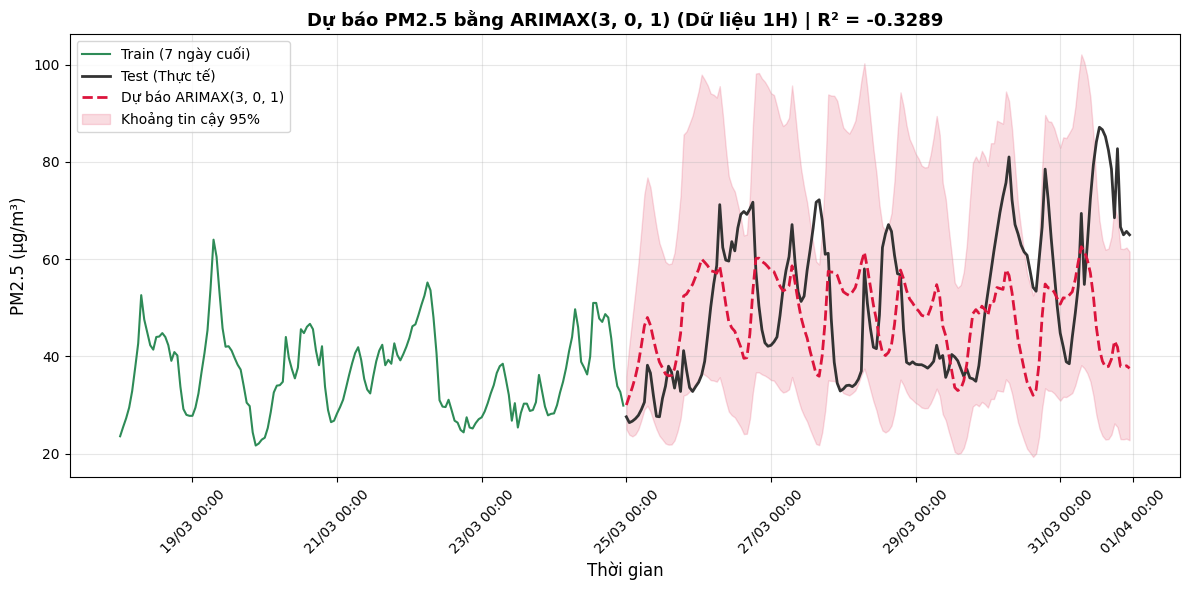

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU NỘI SINH VÀ NGOẠI SINH
# ==========================================
TARGET_COL = 'PM25'
# Chọn lọc các biến ngoại sinh thực sự có tác động (tránh nhiễu)
exog_cols = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity', 'SO2', 'NO2']

# ---> ĐIỂM SỬA 1: Đọc file dữ liệu 1H (Hourly)
train_env = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-hour-new/PM25_2026_Q1_train.csv")
test_env = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-hour-new/PM25_2026_Q1_test_1week.csv")

# Chuyển cột Local Time sang định dạng chuẩn Datetime
train_env['Local Time'] = pd.to_datetime(train_env['Local Time'])
test_env['Local Time'] = pd.to_datetime(test_env['Local Time'])

train_env.set_index('Local Time', inplace=True)
test_env.set_index('Local Time', inplace=True)

# ---> ĐIỂM SỬA 2: Chuyển tần suất về từng giờ ('H')
train_env = train_env.asfreq('H')
test_env = test_env.asfreq('H')

# Lấy dữ liệu ngoại sinh (Exogenous variables)
exog_train = train_env[exog_cols]
exog_test  = test_env[exog_cols]

# Lấy dữ liệu nội sinh (Endogenous variable) và chuyển sang LOG
# (Dùng log1p để an toàn phòng trường hợp có giá trị PM2.5 bằng 0)
endog_train_log = np.log1p(train_env[TARGET_COL])
endog_test_raw  = test_env[TARGET_COL] # Giữ nguyên gốc để lát so sánh lỗi

# ==========================================
# 2. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH ARIMAX
# ==========================================
selected_order = (3, 0, 1)

print(f"Đang huấn luyện ARIMAX{selected_order} với {len(exog_cols)} biến ngoại sinh trên dữ liệu 1H...")

model_arimax = ARIMA(
    endog=endog_train_log, 
    exog=exog_train,       
    order=selected_order,
    trend="n"
)
results_arimax = model_arimax.fit()

print(results_arimax.summary().tables[1]) # In bảng hệ số để xem biến thời tiết nào có ý nghĩa

# ==========================================
# 3. DỰ BÁO TẬP TEST
# ==========================================
n_steps = len(test_env)

# Khi dự báo, BẮT BUỘC phải cung cấp dữ liệu ngoại sinh của tương lai (tập test)
forecast_result = results_arimax.get_forecast(steps=n_steps, exog=exog_test)

# Lấy kết quả dự báo (Đang ở dạng Log)
forecast_log = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int()

# KHÔI PHỤC VỀ KHÔNG GIAN THỰC (np.exp - 1 vì lúc nãy dùng log1p)
forecast_arimax = np.expm1(forecast_log)
lower_arimax = np.expm1(conf_int_log.iloc[:, 0])
upper_arimax = np.expm1(conf_int_log.iloc[:, 1])

forecast_arimax.index = test_env.index

# ==========================================
# 4. ĐÁNH GIÁ CHỈ SỐ METRICS
# ==========================================
# Ép kiểu cho an toàn
y_test_safe = np.asarray(endog_test_raw, dtype=float).flatten()
y_pred_safe = np.asarray(forecast_arimax, dtype=float).flatten()

mae = mean_absolute_error(y_test_safe, y_pred_safe)
rmse = np.sqrt(mean_squared_error(y_test_safe, y_pred_safe))
r2 = r2_score(y_test_safe, y_pred_safe)

nonzero_mask = y_test_safe != 0
mape = np.mean(np.abs((y_test_safe[nonzero_mask] - y_pred_safe[nonzero_mask]) / y_test_safe[nonzero_mask])) * 100

print("\n" + "="*40)
print("KẾT QUẢ ĐÁNH GIÁ ARIMAX (DỮ LIỆU 1H)")
print("="*40)
print(f"MAE  : {mae:.2f} µg/m³")
print(f"RMSE : {rmse:.2f} µg/m³")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# ==========================================
# 5. VẼ ĐỒ THỊ TRỰC QUAN (Phóng to vùng Test)
# ==========================================
plt.figure(figsize=(12, 6))

# ---> ĐIỂM SỬA 3: Zoom vào 168 bước (1 tuần) cuối của train cho dễ nhìn
zoom_steps = 168
train_plot = train_env[TARGET_COL].iloc[-zoom_steps:]

plt.plot(train_plot.index, train_plot.values, color='seagreen', label='Train (7 ngày cuối)')
plt.plot(endog_test_raw.index, endog_test_raw.values, color='#333333', linewidth=2, label='Test (Thực tế)')
plt.plot(forecast_arimax.index, forecast_arimax.values, color='crimson', linestyle='--', linewidth=2, label=f'Dự báo ARIMAX{selected_order}')

plt.fill_between(forecast_arimax.index, lower_arimax, upper_arimax, color='crimson', alpha=0.15, label='Khoảng tin cậy 95%')

plt.title(f"Dự báo PM2.5 bằng ARIMAX{selected_order} (Dữ liệu 1H) | R² = {r2:.4f}", fontsize=13, fontweight='bold')
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Thời gian")
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

# Format trục X để hiển thị ngày và giờ
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:00'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Đọc DL

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
train_valid = pd.read_csv('/kaggle/input/datasets/binhdanghai/data-hour-new/PM25_2026_Q1_train.csv')
test = pd.read_csv('/kaggle/input/datasets/binhdanghai/data-hour-new/PM25_2026_Q1_test_1week.csv')


In [79]:
print("Train - Valid shape:", train_valid.shape)
print("Test shape:", test.shape)

Train - Valid shape: (1992, 16)
Test shape: (168, 16)


In [80]:
print("======= DATA INFO =======")
print(train_valid.info())

======= DATA INFO =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1992 entries, 0 to 1991
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Local Time         1992 non-null   object 
 1   UTC Time           1992 non-null   object 
 2   Country Code       1992 non-null   object 
 3   AQI                1992 non-null   int64  
 4   CO                 1992 non-null   float64
 5   NO2                1992 non-null   float64
 6   O3                 1992 non-null   float64
 7   PM10               1992 non-null   float64
 8   PM25               1992 non-null   float64
 9   SO2                1992 non-null   float64
 10  Clouds             1992 non-null   int64  
 11  Precipitation      1992 non-null   float64
 12  Pressure           1992 non-null   float64
 13  Relative Humidity  1992 non-null   int64  
 14  Temperature        1992 non-null   float64
 15  Wind Speed         1992 non-null   float64
dty

In [81]:
train_valid.head(5)

,Local Time,UTC Time,Country Code,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
0,2026-01-01 00:00:00,2025-12-31 17:00:00+00:00,VN,123,639.0,33.4,50.0,39.5,38.4,32.0,99,0.1,1011.6,95,19.2,8.5
1,2026-01-01 01:00:00,2025-12-31 18:00:00+00:00,VN,122,622.0,31.7,51.0,40.4,39.3,30.4,47,0.0,1011.5,96,19.1,9.2
2,2026-01-01 02:00:00,2025-12-31 19:00:00+00:00,VN,121,553.0,29.4,52.0,39.5,38.4,28.8,71,0.1,1011.2,95,19.0,8.8
3,2026-01-01 03:00:00,2025-12-31 20:00:00+00:00,VN,120,463.0,27.0,55.0,37.7,36.8,27.4,100,0.1,1011.1,96,18.9,9.6
4,2026-01-01 04:00:00,2025-12-31 21:00:00+00:00,VN,118,419.0,26.3,56.0,36.4,35.5,27.3,95,0.1,1011.2,98,18.5,10.0


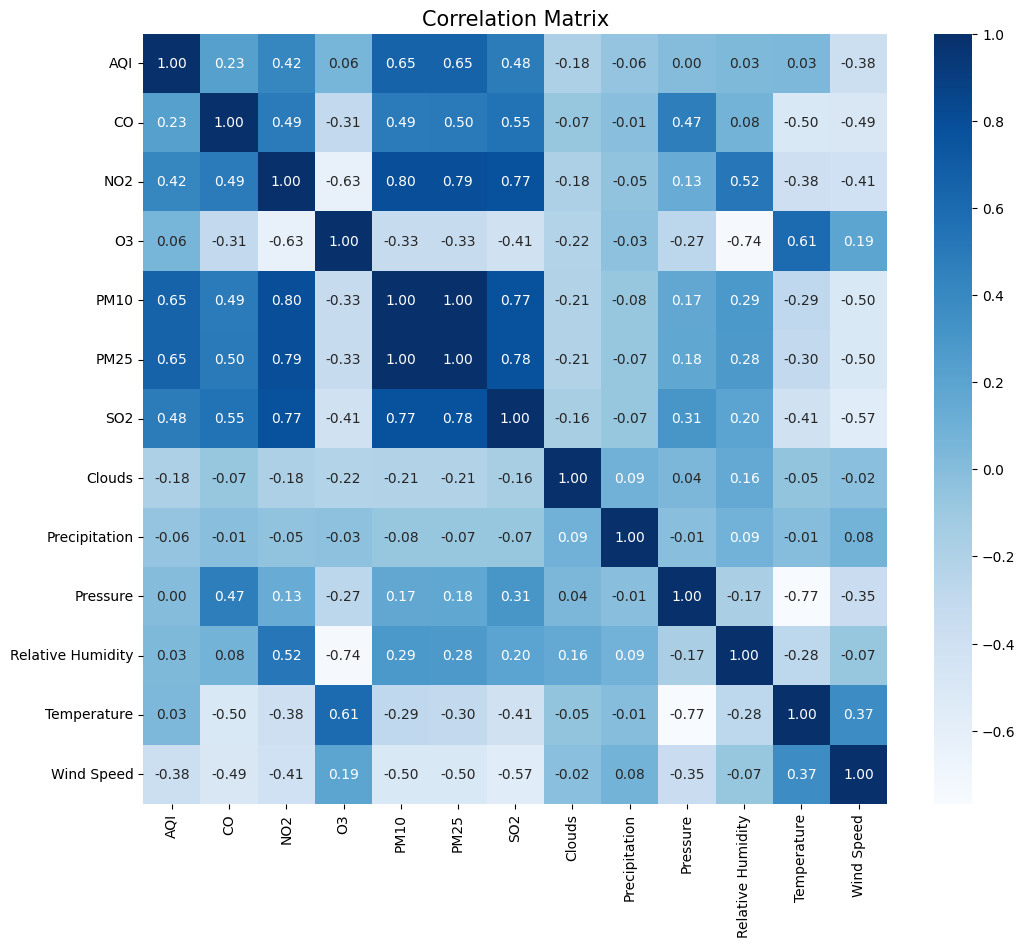

In [82]:
# Ma trận tương quan giữa các biến định lượng
numeric_columns = train_valid.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()



# Feature Engineering
XGBoost cần thôi còn LSTM không cần

In [83]:
from statsmodels.tsa.seasonal import MSTL
from sklearn.preprocessing import StandardScaler

In [84]:
from statsmodels.tsa.seasonal import MSTL

# Hàm trích xuất quy luật mùa vụ (chỉ dùng cho tập train)
def extract_seasonal_profiles(df):
    df_new = df.copy()
    
    df_new['Local Time'] = pd.to_datetime(df_new['Local Time'])
        
    # Phân rã MSTL: Đổi sang chu kỳ 24 (1 ngày) và 72 (3 ngày)
    mstl_model = MSTL(df_new['PM25'], periods=[24, 72])
    res = mstl_model.fit()

    # Lấy các thành phần mùa vụ tương ứng với số chu kỳ đã khai báo
    df_new['seasonal_24'] = res.seasonal['seasonal_24']
    df_new['seasonal_72'] = res.seasonal['seasonal_72']
    
    # Tạo từ điển quy luật mùa vụ theo giờ và tuần
    df_new['hour'] = df_new['Local Time'].dt.hour
    df_new['day_of_week'] = df_new['Local Time'].dt.dayofweek
    
    df_new['month_hour'] = df_new['Local Time'].dt.month.astype(str) + "_" + df_new['hour'].astype(str)
    df_new['month_weekday_hour'] = df_new['Local Time'].dt.month.astype(str) + "_" + df_new['day_of_week'].astype(str) + "_" + df_new['hour'].astype(str)
    
    # Tính trung bình theo nhóm và chuyển thành Dictionary
    profile_24 = df_new.groupby('month_hour')['seasonal_24'].mean().to_dict()
    profile_72 = df_new.groupby('month_weekday_hour')['seasonal_72'].mean().to_dict()    
    
    return profile_24, profile_72

In [85]:
import pandas as pd

# Hàm trích chọn đặc trưng (dùng cho cả train và test - Dữ liệu 1H)
def extract_features(df, profile_24, profile_72, use_env = True):
    df_new = df.copy()
    
    # Chuyển định dạng ngày tháng
    df_new['Local Time'] = pd.to_datetime(df_new['Local Time'])
    
    # Tạo các đặc trưng về thời gian 
    df_new['hour'] = df_new['Local Time'].dt.hour
    df_new['day_of_week'] = df_new['Local Time'].dt.dayofweek
    df_new['month'] = df_new['Local Time'].dt.month
    df_new['season'] = df_new['month'].apply(lambda x: (x%12 + 4)//3)  
    df_new['is_dry_season'] = df_new['month'].isin([11, 12, 1, 2, 3, 4]).astype(int)    
    df_new['is_weekend'] = df_new['day_of_week'].isin([5, 6]).astype(int)
    
    # Ở chu kỳ 1H, cao điểm giao thông thường rơi vào 7-8h sáng và 17-18h tối
    df_new['is_peak_hour'] = df_new['hour'].isin([7, 8, 17, 18]).astype(int)
    
    df_new['month_hour'] = df_new['month'].astype(str) + "_" + df_new['hour'].astype(str)
    df_new['month_weekday_hour'] = df_new['month'].astype(str) + "_" + df_new['day_of_week'].astype(str) + "_" + df_new['hour'].astype(str)
    
    # Map các quy luật mùa vụ đã trích xuất từ tập train
    df_new['seasonal_24'] = df_new['month_hour'].map(profile_24)
    df_new['seasonal_72'] = df_new['month_weekday_hour'].map(profile_72)
    df_new.drop(columns=['month_hour', 'month_weekday_hour'], inplace=True) # Xóa 2 cột trung gian
        
    # Tạo các đặc trưng về lag (1 bước = 1 giờ)
    df_new['pm25_lag3'] = df_new['PM25'].shift(3)      # Lùi 3 giờ
    df_new['pm25_lag24'] = df_new['PM25'].shift(24)    # Lùi 24 giờ (1 ngày)
    
    # Tạo các đặc trưng về rolling (thêm shift(1) để tránh data leakage)
    df_new['pm25_rolling_3h'] = df_new['PM25'].rolling(window=3).mean().shift(1)   # Trung bình 3 giờ
    df_new['pm25_rolling_6h']  = df_new['PM25'].rolling(window=6).mean().shift(1)  # Trung bình 6 giờ
    df_new['pm25_rolling_24h'] = df_new['PM25'].rolling(window=24).mean().shift(1) # Trung bình 24 giờ
    df_new['pm25_rolling_24h_std'] = df_new['PM25'].rolling(window=24).std().shift(1) # Độ lệch chuẩn 24 giờ
    
    # Cập nhật danh sách base_features (Không có lag1)
    base_features = ['hour', 'day_of_week', 'month', 'season', 'is_dry_season', 'is_weekend', 'is_peak_hour',
                     'seasonal_24', 'seasonal_72',
                     'pm25_lag3', 'pm25_lag24',
                     'pm25_rolling_3h', 'pm25_rolling_6h', 'pm25_rolling_24h', 'pm25_rolling_24h_std']
    
    env_features = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity']
    
    features = (env_features + base_features) if use_env else base_features
    return df_new, features

In [86]:
import pandas as pd

# Hàm chuẩn bị dữ liệu 
# Thêm 2 tham số valid_start và test_start để linh hoạt chia tập dữ liệu
def prepare_data(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', use_env=True):
    # Lọc tập train dựa trên mốc thời gian linh hoạt
    train = train_valid[train_valid['Local Time'] < valid_start].copy()
    
    # Trích xuất quy luật mùa vụ từ tập train (Đã đổi tên biến theo dữ liệu 1H)
    profile_24, profile_72 = extract_seasonal_profiles(train)
    
    # Gộp dữ liệu để tính Lag/Rolling không bị hụt ở đầu tập Valid/Test
    combined = pd.concat([train_valid, test], ignore_index=True)
    combined.sort_values('Local Time', inplace=True)    # Sắp xếp theo thời gian
    combined.reset_index(drop=True, inplace=True)       # Cập nhật lại index
    
    # Trích chọn đặc trưng cho cả 3 tập (Truyền đúng tên profile_24, profile_72)
    data_prepared, features = extract_features(combined, profile_24, profile_72, use_env)
    
    # Chia lại train, valid, test dựa trên mốc thời gian mới
    train = data_prepared[data_prepared['Local Time'] < valid_start].copy()
    valid = data_prepared[(data_prepared['Local Time'] >= valid_start) & (data_prepared['Local Time'] < test_start)].copy()
    test  = data_prepared[data_prepared['Local Time'] >= test_start].copy()
    
    # Xóa các hàng có giá trị NaN do việc tạo đặc trưng lag và rolling (Chỉ làm trên Train)
    train = train.dropna(subset=features + ['PM25']).reset_index(drop=True)
    
    # Tách features và target
    X_train = train[features].values
    y_train = train['PM25'].values
    
    X_valid = valid[features].values
    y_valid = valid['PM25'].values
    
    X_test = test[features].values
    y_test = test['PM25'].values
    
    print("Đã chuẩn bị xong dữ liệu :>")
    print("Train shape:", X_train.shape, y_train.shape)
    print("Valid shape:", X_valid.shape, y_valid.shape)
    print("Test shape:", X_test.shape, y_test.shape)

    return X_train, y_train, X_valid, y_valid, X_test, y_test, features

In [87]:
X_train_all_ft, y_train, X_valid_all_ft, y_valid, X_test_all_ft, y_test, features = prepare_data(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', use_env=True)

Đã chuẩn bị xong dữ liệu :>
Train shape: (1392, 21) (1392,)
Valid shape: (576, 21) (576,)
Test shape: (168, 21) (168,)


# Modeling

In [89]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [90]:
def evaluate_model(y_true, y_pred, model_name="MÔ HÌNH", scaler=None, n_features=None, target_idx=None):

    # Ép về mảng 1 chiều tránh lỗi kích thước
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Map về giá trị gốc
    if scaler is not None and n_features is not None and target_idx is not None:
        # Tạo ma trận giả cho y_true
        dummy_true = np.zeros((len(y_true), n_features))
        dummy_true[:, target_idx] = y_true
        y_true_real = scaler.inverse_transform(dummy_true)[:, target_idx]
            
        # Tạo ma trận giả cho y_pred
        dummy_pred = np.zeros((len(y_pred), n_features))
        dummy_pred[:, target_idx] = y_pred
        y_pred_real = scaler.inverse_transform(dummy_pred)[:, target_idx]
        
    else:
        y_true_real = y_true
        y_pred_real = y_pred
        
    mae = mean_absolute_error(y_true_real, y_pred_real)
    mse = mean_squared_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_real, y_pred_real)
    
    # In kết quả
    print(f"\n========== KẾT QUẢ: {model_name.upper()} ==========")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print("=========================================")
    
    return y_true_real, y_pred_real

## XGBoost

In [91]:
def xgboost_pipeline(X_train, y_train, X_valid, y_valid): 
    
    # Định nghĩa các bước trong pipeline
    pipeline = Pipeline([
        ('model', XGBRegressor(
            n_estimators=100, 
            learning_rate=0.1, 
            max_depth=6, 
            random_state=42, 
            early_stopping_rounds=10))
    ])
    
    # Huấn luyện mô hình
    pipeline.fit(X_train, y_train, 
                 model__eval_set=[(X_valid, y_valid)],     # early stopping dựa trên cả tập validation
                 model__verbose=100)                  # In kết quả sau mỗi 100 vòng
    
    print("Hoàn tất huấn luyện mô hình XGBoost")
    
    return pipeline

In [92]:
model_xgboost = xgboost_pipeline(X_train_all_ft, y_train, X_valid_all_ft, y_valid)

y_pred_valid_xgb = model_xgboost.predict(X_valid_all_ft)

y_valid_pred, y_pred_xgb = evaluate_model(
    y_true=y_valid, 
    y_pred=y_pred_valid_xgb, 
    model_name="XGBoost"
)

[0]	validation_0-rmse:23.71099
[99]	validation_0-rmse:7.71567
Hoàn tất huấn luyện mô hình XGBoost

========== KẾT QUẢ: XGBOOST ==========
MAE:  5.0663
MSE:  59.5316
RMSE: 7.7157
R2:   0.8984


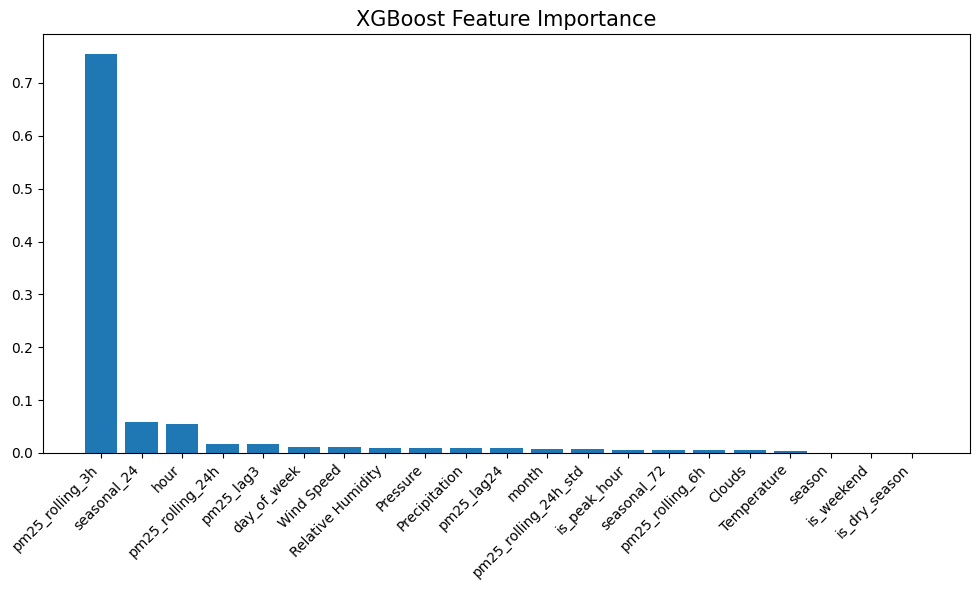

In [93]:
feat_imp = model_xgboost.named_steps['model'].feature_importances_
sorted_idx = np.argsort(feat_imp)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(features)), feat_imp[sorted_idx])
plt.xticks(range(len(features)), [features[i] for i in sorted_idx], rotation=45, ha='right')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

pm25_lag1 được sử dụng nhiều và giúp mô hình giảm nhiều sai số nhất (nhưng không biết có quan hệ phi tuyến hay tuyến tính với biến dự đoán hay không)

## LSTM

In [94]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import time

In [95]:
# Set seed thư viện tf
tf.random.set_seed(42)

# Hàm tạo các chuỗi dữ liệu cho LSTM
def create_sequences(data, target_index, steps):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i: i + steps, :])     # Dữ liệu đầu vào (cửa sổ trượt)
        y.append(data[i + steps, target_index])    # Giá trị PM25 tại t+1
        
    return np.array(X), np.array(y)

# Hàm chuyển dữ liệu về dạng 3D cho LSTM
# Thêm valid_start, test_start và đổi mặc định time_steps=4 (1 ngày dữ liệu 6H)
def prepare_data_lstm(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', time_steps=4, use_env=True):
    
    env_features = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity', 'SO2', 'NO2']
    base_features = ['PM25']
    features = (env_features + base_features) if use_env else base_features
    
    # Chia tập dữ liệu dựa trên mốc thời gian động
    train = train_valid[train_valid['Local Time'] < valid_start].copy()
    valid = train_valid[(train_valid['Local Time'] >= valid_start) & (train_valid['Local Time'] < test_start)].copy()

    # Trích xuất numpy array
    train_data = train[features].values
    valid_data = valid[features].values
    test_data = test[features].values
    
    # Chuẩn hóa dữ liệu (Fit scaler chỉ trên tập Train để tránh Data Leakage)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_data)
    valid_scaled = scaler.transform(valid_data)
    test_scaled = scaler.transform(test_data)
    
    # Vị trí cột PM25
    pm25_index = features.index('PM25')
    
    # --- XỬ LÝ CHỐNG MẤT DỮ LIỆU Ở ĐẦU TẬP VALID VÀ TEST ---
    # Mượn time_steps dòng cuối của tập trước nối vào đầu tập sau
    valid_scaled_extended = np.vstack((train_scaled[-time_steps:], valid_scaled))
    test_scaled_extended = np.vstack((valid_scaled[-time_steps:], test_scaled))
    
    # Tạo các chuỗi dữ liệu cho LSTM
    X_train, y_train = create_sequences(train_scaled, pm25_index, time_steps)
    X_valid, y_valid = create_sequences(valid_scaled_extended, pm25_index, time_steps)
    X_test, y_test = create_sequences(test_scaled_extended, pm25_index, time_steps)
    
    print("Đã chuẩn bị xong dữ liệu 3D cho LSTM :>")
    print("Train shape:", X_train.shape, y_train.shape)
    print("Valid shape:", X_valid.shape, y_valid.shape)
    print("Test shape:", X_test.shape, y_test.shape)
    
    return X_train, y_train, X_valid, y_valid, X_test, y_test, scaler, features

In [96]:
# Hàm huấn luyện LSTM
# ---> ĐIỂM SỬA 1: Tăng batch_size lên 64 do dữ liệu 1H có số lượng dòng lớn hơn nhiều so với 6H
def lstm_model(X_train, y_train, X_valid, y_valid, batch_size=64, epochs=100):
    start_time = time.time()
    
    n_time_steps = X_train.shape[1]
    n_features = X_train.shape[2]
    
    model = Sequential([
        Input(shape=(n_time_steps, n_features)),
        
        # Lớp 1: Quét qua chuỗi dữ liệu quá khứ để học quy luật ngắn hạn
        LSTM(64, return_sequences=True, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),     # Thêm L2 chống overfitting
        Dropout(0.4),     # Tránh overfitting
        
        # Lớp 2: Nén các đặc trưng cốt lõi 
        LSTM(32, return_sequences=False, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(0.4),
        
        # Đầu ra dự báo 
        Dense(16, activation='relu'),
        Dense(1)  # Dự đoán PM2.5
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Dừng sớm nếu loss không giảm sau 10 vòng
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True
    )
    
    # ReduceLROnPlateau: giảm Learning Rate khi val_loss chững lại
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # Giảm LR đi một nửa
        patience=5,            # Đợi 5 epoch không cải thiện thì giảm
        min_lr=1e-6,
        verbose=1
    )
    
    # Huấn luyện mô hình
    history = model.fit(X_train, y_train, 
                        validation_data=(X_valid, y_valid), 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        callbacks=[early_stopping, reduce_lr],
                        verbose=1)     
    
    print(f"Hoàn tất huấn luyện mô hình LSTM: {time.time() - start_time:.2f} giây")
    return model, history

In [97]:
# Cách gọi hàm (bạn tự điều chỉnh mốc thời gian và time_steps cho phù hợp)
X_train_seq, y_train_seq, X_valid_seq, y_valid_seq, X_test_seq, y_test_seq, scaler, features_lstm = prepare_data_lstm(
    train_valid=train_valid, 
    test=test, 
    valid_start='2026-03-01', 
    test_start='2026-03-15', 
    time_steps=8,  # Lùi về quá khứ 8 buổi (2 ngày)
    use_env=True
)

print("X train shape:", X_train_seq.shape)

Đã chuẩn bị xong dữ liệu 3D cho LSTM :>
Train shape: (1408, 8, 9) (1408,)
Valid shape: (336, 8, 9) (336,)
Test shape: (168, 8, 9) (168,)
X train shape: (1408, 8, 9)


In [98]:
model_lstm, history = lstm_model(X_train_seq, y_train_seq, X_valid_seq, y_valid_seq)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.8466 - mae: 0.7067 - val_loss: 0.3557 - val_mae: 0.4372 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4018 - mae: 0.4582 - val_loss: 0.2521 - val_mae: 0.3560 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2766 - mae: 0.3902 - val_loss: 0.1970 - val_mae: 0.3279 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2201 - mae: 0.3544 - val_loss: 0.1850 - val_mae: 0.3170 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1991 - mae: 0.3248 - val_loss: 0.1786 - val_mae: 0.3176 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1902 - mae: 0.3209 - val_loss: 0.1572 - val_mae: 0.2953 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1743 - mae: 0.3025 - val_loss: 0.1412 - val_mae: 0.2818 - learning_rate: 0.0010
Epoch 

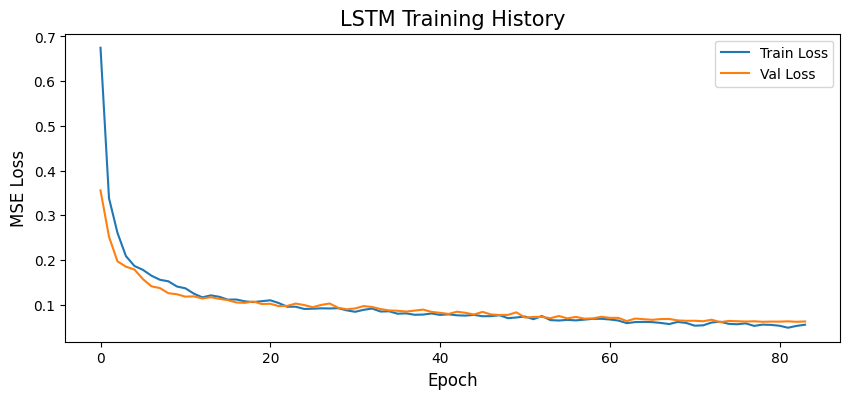

In [99]:
# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

Dùng ReduceLR nên đã giảm được tình trạng overfitting ban đầu :< 

In [100]:
# Đánh giá mô hình lstm
y_valid_pred_scaled_lstm = model_lstm.predict(X_valid_seq)

y_valid, y_pred_lstm = evaluate_model(
    y_true=y_valid_seq, 
    y_pred=y_valid_pred_scaled_lstm, 
    model_name="LSTM",
    scaler=scaler,  
    n_features=X_train_seq.shape[2],
    target_idx=features_lstm.index('PM25')
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

========== KẾT QUẢ: LSTM ==========
MAE:  5.7241
MSE:  56.6250
RMSE: 7.5250
R2:   0.9247


# Thực nghiệm

In [101]:
results = {}  # Lưu kết quả để so sánh cuối

# XGBoost
for use_env in [True, False]:
    label = "XGBoost_env" if use_env else "XGBoost_no_env"
    
    # Tính thời gian từ bước tạo features
    t_start = time.time()
    X_train, y_train, X_valid, y_valid, X_test, y_test, features = prepare_data(train_valid, test, use_env=use_env)
    model = xgboost_pipeline(X_train, y_train, X_valid, y_valid)
    t_elapsed = time.time() - t_start
    
    # Đánh giá
    y_pred = model.predict(X_valid)
    _, y_pred_real = evaluate_model(y_valid, y_pred, model_name=label)
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây")
    
    results[label] = {
        'model': model,
        'time': t_elapsed,
        'y_valid': y_valid,
        'y_pred': y_pred_real
    }

# LSTM 
for use_env in [True, False]:
    label = "LSTM_env" if use_env else "LSTM_no_env"
    
    t_start = time.time()
    X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler, features_lstm = prepare_data_lstm(train_valid, test, use_env=use_env)
    model_lstm, history = lstm_model(X_tr, y_tr, X_vl, y_vl)
    t_elapsed = time.time() - t_start
    
    # Đánh giá
    y_pred = model_lstm.predict(X_vl)
    y_true_real, y_pred_real = evaluate_model(y_vl, y_pred, model_name=label,
                                    scaler=scaler,
                                    n_features=len(features_lstm),
                                    target_idx=features_lstm.index('PM25'))
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây")
    
    
    results[label] = {
        'model': model_lstm,
        'scaler': scaler,
        'time': t_elapsed,
        'history': history,
        'y_valid': y_true_real,
        'y_pred': y_pred_real
    }

Đã chuẩn bị xong dữ liệu :>
Train shape: (1392, 21) (1392,)
Valid shape: (576, 21) (576,)
Test shape: (168, 21) (168,)
[0]	validation_0-rmse:23.71099
[99]	validation_0-rmse:7.71567
Hoàn tất huấn luyện mô hình XGBoost

========== KẾT QUẢ: XGBOOST_ENV ==========
MAE:  5.0663
MSE:  59.5316
RMSE: 7.7157
R2:   0.8984
Tổng thời gian (XGBoost_env): 0.38 giây
Đã chuẩn bị xong dữ liệu :>
Train shape: (1392, 15) (1392,)
Valid shape: (576, 15) (576,)
Test shape: (168, 15) (168,)
[0]	validation_0-rmse:23.65847
[60]	validation_0-rmse:7.69871
Hoàn tất huấn luyện mô hình XGBoost

========== KẾT QUẢ: XGBOOST_NO_ENV ==========
MAE:  5.0251
MSE:  59.1275
RMSE: 7.6894
R2:   0.8991
Tổng thời gian (XGBoost_no_env): 0.30 giây
Đã chuẩn bị xong dữ liệu 3D cho LSTM :>
Train shape: (1412, 4, 9) (1412,)
Valid shape: (576, 4, 9) (576,)
Test shape: (168, 4, 9) (168,)
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1.0293 - mae: 0.7663 - val_loss: 0.3456 - val_mae: 0.4650 - learning_rate: 0.0010
Epoch 2

In [102]:
xgb_core = model.steps[-1][1] if hasattr(model, 'steps') else model
    
if hasattr(xgb_core, 'best_iteration'):
    best_n_trees = xgb_core.best_iteration + 1
    print(f"[{label}] Số cây (best_n_estimators) tối ưu: {best_n_trees}")
else:
    print(f"[{label}] Không tìm thấy best_iteration")

[LSTM_no_env] Số cây (best_n_estimators) tối ưu: 51


In [103]:
# Bảng tổng kết
print("\n" + "="*60)
print("TỔNG KẾT CÁC THỰC NGHIỆM")
print("="*60)
print(f"{'Mô hình':<25} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'Time(s)':>10}")
print("-"*60)
for label, res in results.items():
    mae  = mean_absolute_error(res['y_valid'], res['y_pred'])
    rmse = np.sqrt(mean_squared_error(res['y_valid'], res['y_pred']))
    r2   = r2_score(res['y_valid'], res['y_pred'])
    print(f"{label:<25} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f} {res['time']:>10.2f}")
print("="*60)


TỔNG KẾT CÁC THỰC NGHIỆM
Mô hình                        MAE     RMSE       R2    Time(s)
------------------------------------------------------------
XGBoost_env                 5.0663   7.7157   0.8984       0.38
XGBoost_no_env              5.0251   7.6894   0.8991       0.30
LSTM_env                    3.5976   5.0566   0.9564      25.93
LSTM_no_env                 3.0807   5.1226   0.9552      26.20


## Test

In [104]:
from tensorflow.keras.optimizers import Adam

In [105]:
# Gộp train - valid
def xgboost_pipeline_final(X_train, y_train, best_n_estimators=74):

    print(f"Đang huấn luyện XGBoost với {best_n_estimators} cây cố định...")
    
    # Khởi tạo mô hình 
    model = XGBRegressor(
        n_estimators=best_n_estimators,
        learning_rate=0.05, 
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    
    # Chỉ fit trên tập Train (lúc này là tập gộp Train + Valid)
    model.fit(X_train, y_train)
    
    return model


# Không có early stopping, LR cố định
def lstm_model_final(X_train, y_train, best_epochs=20):
    print(f"Đang huấn luyện LSTM với {best_epochs} epochs cố định...")
    
    n_time_steps = X_train.shape[1]
    n_features = X_train.shape[2]
    
    model = Sequential([
        Input(shape=(n_time_steps, n_features)),
        
        # Lớp 1: Quét qua chuỗi dữ liệu quá khứ để học quy luật ngắn hạn
        LSTM(64, return_sequences=True, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),     # thêm L2 chống overfitting
        Dropout(0.4),     # Tránh overfitting
        
        # Lớp 2: Nén các đặc trưng cốt lõi 
        LSTM(32, return_sequences=False, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(0.4),
        
        # Đầu ra dự báo 
        Dense(16, activation='relu'),
        Dense(1)  # Dự đoán PM2.5
    ])
    
    # Sử dụng Learning Rate cố định đã tối ưu
    optimizer = Adam(learning_rate=2.5e-4) 
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    # Fit mô hình không có Valid
    history = model.fit(
        X_train, y_train,
        epochs=best_epochs,  
        batch_size=64,       # <-- SỬA: Hạ xuống 16 để model học mượt hơn với lượng dữ liệu gộp 6H
        verbose=1            
    )
    
    return model, history

In [106]:
results_test = {}

# XGBOOST TRÊN TẬP TRAIN_FINAL 
for use_env in [True, False]:
    label = "XGBoost_env_Final" if use_env else "XGBoost_no_env_Final"
    
    t_start = time.time()
    
    
    # Lấy dữ liệu (Chỉ lấy X_tr_final, y_tr_final và X_te, y_te)
    X_tr_final, y_tr_final, _, _, X_te, y_te, features = prepare_data(train_valid, test, use_env=use_env)
    
    # Huấn luyện trên tập gộp. 
    model_xgb = xgboost_pipeline_final(X_tr_final, y_tr_final, best_n_estimators=74)
    t_elapsed = time.time() - t_start
    
    # Đánh giá trên tập Test
    y_pred = model_xgb.predict(X_te)
    _, y_pred_real = evaluate_model(y_te, y_pred, model_name=label)
    
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây\n")
    
    results_test[label] = {
        'model': model_xgb,
        'time': t_elapsed,
        'y_test': y_te,
        'y_pred': y_pred_real
    }

# LSTM TRÊN TẬP TRAIN_FINAL 
for use_env in [True, False]:
    label = "LSTM_env_Final" if use_env else "LSTM_no_env_Final"
    
    t_start = time.time()
    
    # Lấy dữ liệu
    X_tr_final, y_tr_final, _, _, X_te, y_te, scaler, features_lstm = prepare_data_lstm(train_valid, test, use_env=use_env)
    
    # Huấn luyện trên tập gộp. 
    model_lstm, history = lstm_model_final(X_tr_final, y_tr_final, best_epochs=20) 
    t_elapsed = time.time() - t_start
    
    # Đánh giá trên tập Test
    y_pred = model_lstm.predict(X_te)
    y_true_real, y_pred_real = evaluate_model(y_te, y_pred, model_name=label,
                                    scaler=scaler,
                                    n_features=len(features_lstm),
                                    target_idx=features_lstm.index('PM25'))
    
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây\n")
    
    results_test[label] = {
        'model': model_lstm,
        'scaler': scaler,
        'time': t_elapsed,
        'history': history,
        'y_test': y_true_real,
        'y_pred': y_pred_real
    }

Đã chuẩn bị xong dữ liệu :>
Train shape: (1392, 21) (1392,)
Valid shape: (576, 21) (576,)
Test shape: (168, 21) (168,)
Đang huấn luyện XGBoost với 74 cây cố định...

========== KẾT QUẢ: XGBOOST_ENV_FINAL ==========
MAE:  5.0775
MSE:  45.8923
RMSE: 6.7744
R2:   0.8075
Tổng thời gian (XGBoost_env_Final): 0.33 giây

Đã chuẩn bị xong dữ liệu :>
Train shape: (1392, 15) (1392,)
Valid shape: (576, 15) (576,)
Test shape: (168, 15) (168,)
Đang huấn luyện XGBoost với 74 cây cố định...

========== KẾT QUẢ: XGBOOST_NO_ENV_FINAL ==========
MAE:  5.3296
MSE:  52.1591
RMSE: 7.2221
R2:   0.7812
Tổng thời gian (XGBoost_no_env_Final): 0.30 giây

Đã chuẩn bị xong dữ liệu 3D cho LSTM :>
Train shape: (1412, 4, 9) (1412,)
Valid shape: (576, 4, 9) (576,)
Test shape: (168, 4, 9) (168,)
Đang huấn luyện LSTM với 20 epochs cố định...
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.9598 - mae: 0.7440
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7958 - mae: 0.6778
Epoch 3/20
23/23 ━━━━━━

In [107]:
# Bảng tổng kết
print("\n" + "="*60)
print("TỔNG KẾT CÁC THỰC NGHIỆM")
print("="*60)
print(f"{'Mô hình':<25} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'Time(s)':>10}")
print("-"*60)
for label, res in results_test.items():
    mae  = mean_absolute_error(res['y_test'], res['y_pred'])
    rmse = np.sqrt(mean_squared_error(res['y_test'], res['y_pred']))
    r2   = r2_score(res['y_test'], res['y_pred'])
    print(f"{label:<25} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f} {res['time']:>10.2f}")
print("="*60)


TỔNG KẾT CÁC THỰC NGHIỆM
Mô hình                        MAE     RMSE       R2    Time(s)
------------------------------------------------------------
XGBoost_env_Final           5.0775   6.7744   0.8075       0.33
XGBoost_no_env_Final        5.3296   7.2221   0.7812       0.30
LSTM_env_Final              9.7933  12.3810   0.3570       5.99
LSTM_no_env_Final           7.0113   9.0188   0.6588       6.52


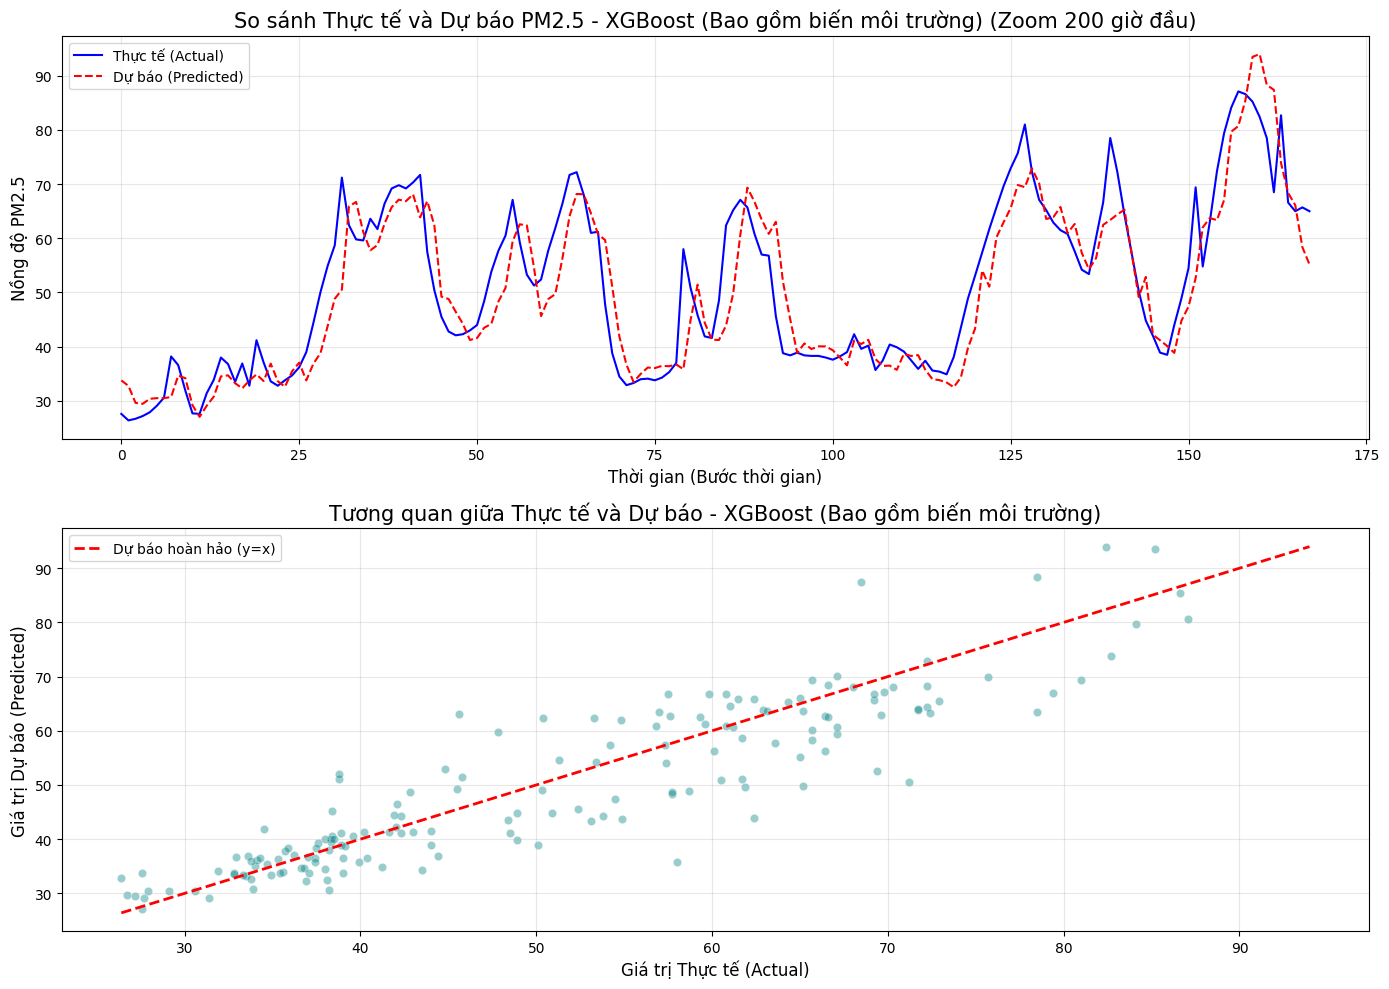

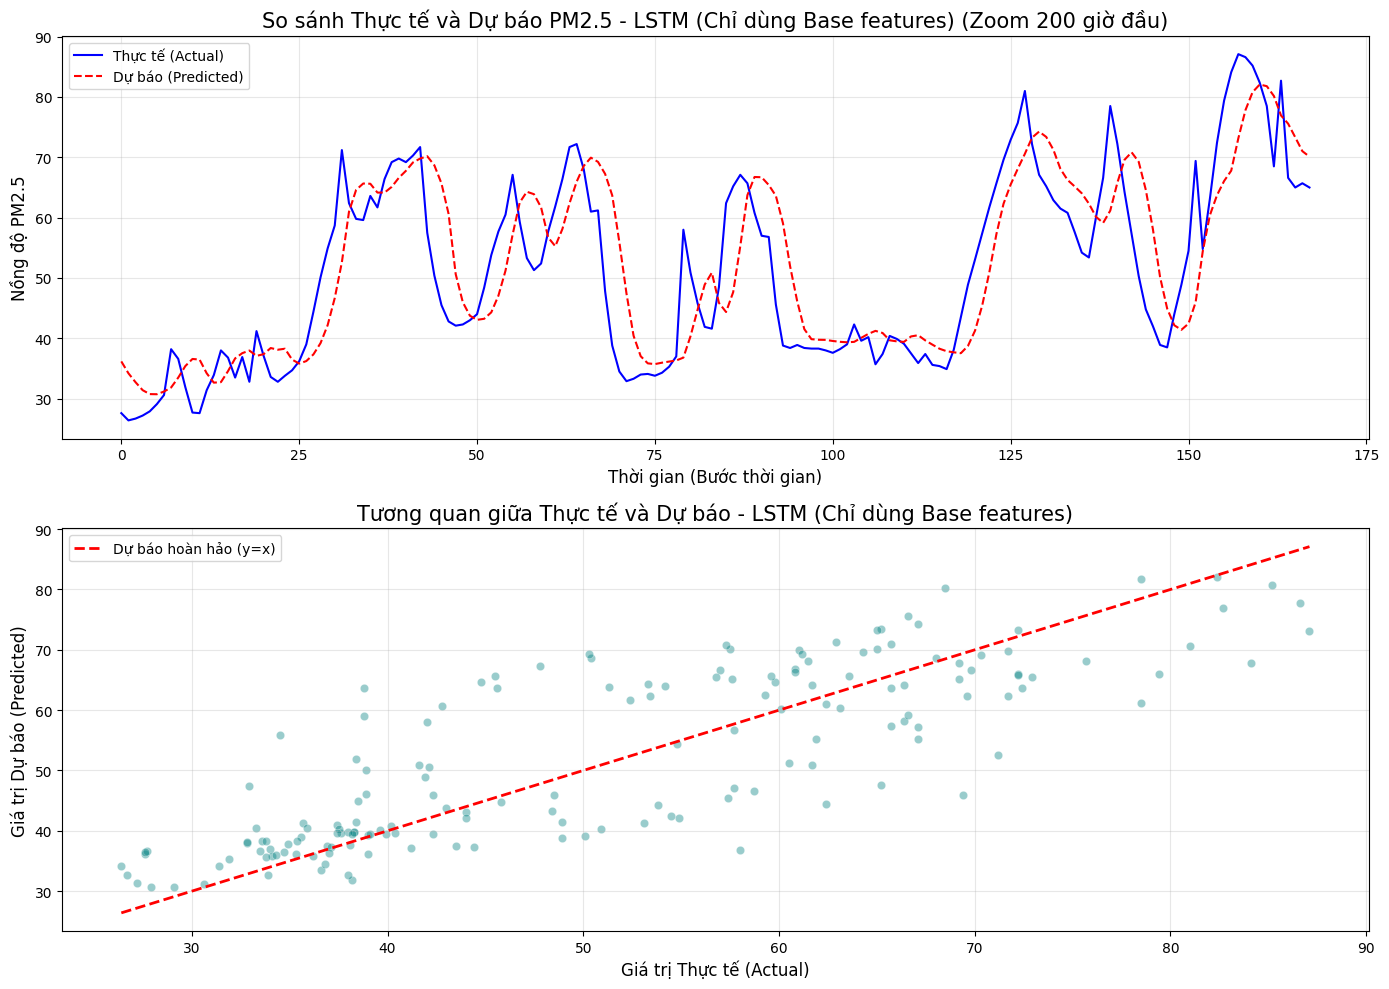

In [108]:
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name="Mô hình", num_points=200):
    """
    Hàm vẽ đồ thị so sánh giá trị thực tế và dự báo PM2.5.
    y_true: mảng giá trị thực tế.
    y_pred: mảng giá trị dự báo.
    num_points: số lượng điểm dữ liệu cắt ra để vẽ biểu đồ đường (giúp dễ quan sát hơn).
    """
    # Đảm bảo dữ liệu ở dạng mảng 1 chiều
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    plt.figure(figsize=(14, 10))

    # --- 1. Biểu đồ đường (Line Plot) theo thời gian ---
    plt.subplot(2, 1, 1)
    # Lấy num_points điểm đầu tiên (hoặc có thể đổi thành khoảng thời gian bạn muốn)
    plt.plot(y_true[:num_points], label='Thực tế (Actual)', color='blue', linewidth=1.5)
    plt.plot(y_pred[:num_points], label='Dự báo (Predicted)', color='red', linestyle='--', linewidth=1.5)
    
    plt.title(f'So sánh Thực tế và Dự báo PM2.5 - {model_name} (Zoom {num_points} giờ đầu)')
    plt.xlabel('Thời gian (Bước thời gian)')
    plt.ylabel('Nồng độ PM2.5')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- 2. Biểu đồ phân tán (Scatter Plot) tương quan ---
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, color='teal')
    
    # Vẽ đường chéo y = x (hoàn hảo)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Dự báo hoàn hảo (y=x)')

    plt.title(f'Tương quan giữa Thực tế và Dự báo - {model_name}')
    plt.xlabel('Giá trị Thực tế (Actual)')
    plt.ylabel('Giá trị Dự báo (Predicted)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH GỌI HÀM VỚI DỮ LIỆU CỦA BẠN
# ==========================================
# Dựa vào dictionary `results_test` bạn đã lưu ở bước đánh giá trước đó:

# Vẽ cho mô hình XGBoost (có biến môi trường)
y_test_xgb = results_test['XGBoost_env_Final']['y_test']
y_pred_xgb = results_test['XGBoost_env_Final']['y_pred']
plot_actual_vs_predicted(y_test_xgb, y_pred_xgb, model_name="XGBoost (Bao gồm biến môi trường)", num_points=200)

#Vẽ cho mô hình LSTM (không có biến môi trường)
y_test_lstm = results_test['LSTM_no_env_Final']['y_test']
y_pred_lstm = results_test['LSTM_no_env_Final']['y_pred']
plot_actual_vs_predicted(y_test_lstm, y_pred_lstm, model_name="LSTM (Chỉ dùng Base features)", num_points=200)

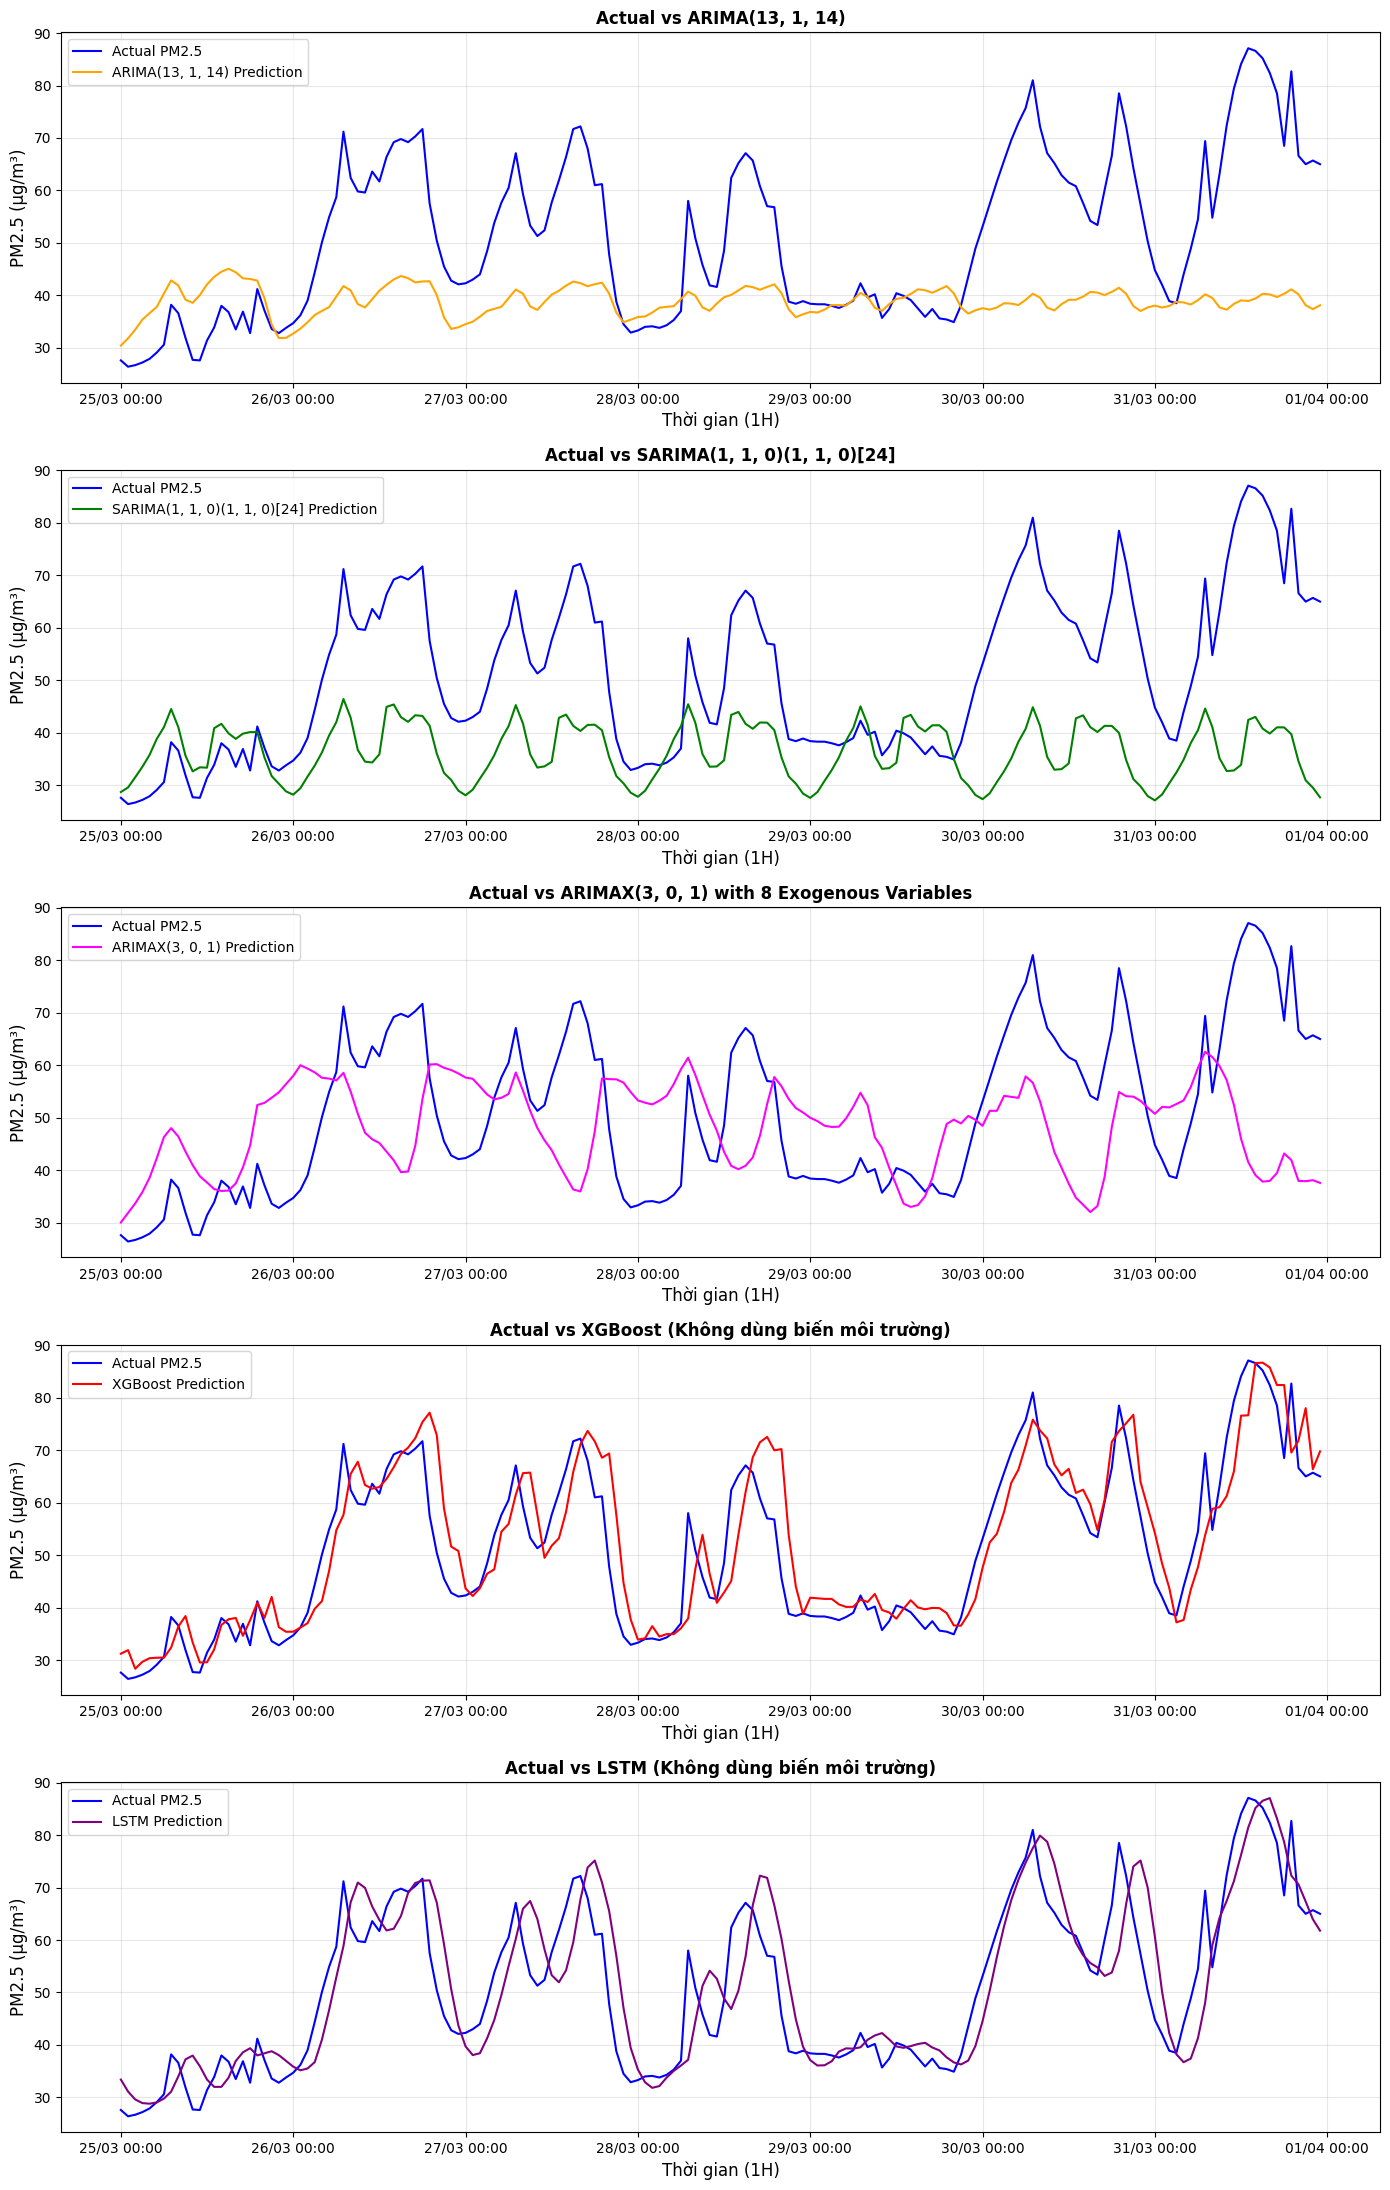

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==============================================================================
# BƯỚC 1: TRÍCH XUẤT VÀ ÉP KIỂU DỮ LIỆU (CHỐNG LỖI MATPLOTLIB)
# ==============================================================================
# Trích xuất trục thời gian trực tiếp từ kết quả dự báo ARIMAX (đã là DatetimeIndex chuẩn)
time_index = forecast_arimax.index

# 1. Dữ liệu ARIMA(13, 1, 14) 
y_actual_arima = np.asarray(endog_test_raw, dtype=float).flatten()
y_pred_arima = np.asarray(arima_forecast, dtype=float).flatten()

# 2. Dữ liệu SARIMA(1, 1, 0)(1, 1, 0)[24]
y_actual_sarima = np.asarray(endog_test_raw, dtype=float).flatten()
y_pred_sarima = np.asarray(sarima_forecast, dtype=float).flatten()

# 3. Dữ liệu ARIMAX(3, 0, 1) với biến ngoại sinh
y_actual_arimax = np.asarray(endog_test_raw, dtype=float).flatten()
y_pred_arimax = np.asarray(forecast_arimax, dtype=float).flatten()

# 4. Dữ liệu XGBoost (Không môi trường)
y_actual_xgb = np.asarray(results_test['XGBoost_no_env_Final']['y_test'], dtype=float).flatten()
y_pred_xgb = np.asarray(results_test['XGBoost_no_env_Final']['y_pred'], dtype=float).flatten()

# 5. Dữ liệu LSTM (Không môi trường)
y_actual_lstm = np.asarray(results_test['LSTM_no_env_Final']['y_test'], dtype=float).flatten()
y_pred_lstm = np.asarray(results_test['LSTM_no_env_Final']['y_pred'], dtype=float).flatten()

# ==============================================================================
# BƯỚC 2: KHỞI TẠO FIGURE VÀ 5 SUBPLOTS THEO CHIỀU DỌC
# ==============================================================================
# Chỉnh nrows=5 và tăng chiều cao figsize lên 22 để 5 hình rộng rãi
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 22))

# ==============================================================================
# BƯỚC 3: VẼ TỪNG ĐỒ THỊ
# ==============================================================================

# --- ĐỒ THỊ 1: ARIMA ---
axes[0].plot(time_index, y_actual_arima, color='blue', label='Actual PM2.5')
axes[0].plot(time_index, y_pred_arima, color='orange', label='ARIMA(13, 1, 14) Prediction')
axes[0].set_title("Actual vs ARIMA(13, 1, 14)", fontsize=12, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_xlabel('Thời gian (1H)')
axes[0].legend(loc='upper left')

# --- ĐỒ THỊ 2: SARIMA ---
axes[1].plot(time_index, y_actual_sarima, color='blue', label='Actual PM2.5')
axes[1].plot(time_index, y_pred_sarima, color='green', label='SARIMA(1, 1, 0)(1, 1, 0)[24] Prediction')
axes[1].set_title("Actual vs SARIMA(1, 1, 0)(1, 1, 0)[24]", fontsize=12, fontweight='bold')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_xlabel('Thời gian (1H)')
axes[1].legend(loc='upper left')

# --- ĐỒ THỊ 3: ARIMAX ---
axes[2].plot(time_index, y_actual_arimax, color='blue', label='Actual PM2.5')
axes[2].plot(time_index, y_pred_arimax, color='magenta', label='ARIMAX(3, 0, 1) Prediction')
axes[2].set_title("Actual vs ARIMAX(3, 0, 1) with 8 Exogenous Variables", fontsize=12, fontweight='bold')
axes[2].set_ylabel('PM2.5 (µg/m³)')
axes[2].set_xlabel('Thời gian (1H)')
axes[2].legend(loc='upper left')

# --- ĐỒ THỊ 4: XGBoost ---
axes[3].plot(time_index, y_actual_xgb, color='blue', label='Actual PM2.5')
axes[3].plot(time_index, y_pred_xgb, color='red', label='XGBoost Prediction')
axes[3].set_title("Actual vs XGBoost (Không dùng biến môi trường)", fontsize=12, fontweight='bold')
axes[3].set_ylabel('PM2.5 (µg/m³)')
axes[3].set_xlabel('Thời gian (1H)')
axes[3].legend(loc='upper left')

# --- ĐỒ THỊ 5: LSTM ---
axes[4].plot(time_index, y_actual_lstm, color='blue', label='Actual PM2.5')
axes[4].plot(time_index, y_pred_lstm, color='purple', label='LSTM Prediction') 
axes[4].set_title("Actual vs LSTM (Không dùng biến môi trường)", fontsize=12, fontweight='bold')
axes[4].set_ylabel('PM2.5 (µg/m³)')
axes[4].set_xlabel('Thời gian (1H)')
axes[4].legend(loc='upper left')

# ==============================================================================
# BƯỚC 4: TINH CHỈNH VÀ HIỂN THỊ TRỰC QUAN
# ==============================================================================
for ax in axes:
    # Dữ liệu 1H nên thêm %H:00 để thấy rõ diễn biến từng giờ
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:00'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()